# Customer Behaviour Analysis

# Objective
In this case study, you will be working on E-commerce Customer Behavior Analysis using Apache Spark, a powerful distributed computing framework designed for big data processing. This assignment aims to give you hands-on experience in analyzing large-scale e-commerce datasets using PySpark. You will apply techniques learned in data analytics to clean, transform, and explore customer behavior data, drawing meaningful insights to support business decision-making. Apart from understanding how big data tools can optimize performance on a single machine and across clusters, you will develop a structured approach to analyzing customer segmentation, purchase patterns, and behavioral trends.

# Business Value
E-commerce businesses operate in a highly competitive market where understanding customer behavior is critical to driving growth and retention. To stay ahead, companies must leverage data-driven insights to optimize marketing strategies, personalize customer experiences, and improve product offerings. In this assignment, you will analyze e-commerce transaction data to uncover patterns in purchasing behavior, customer preferences, and sales performance. With Apache Spark's ability to handle large datasets efficiently, businesses can process vast amounts of customer interactions in real-time, helping them make faster and more informed decisions.
As an analyst at an e-commerce company, your task is to examine historical transaction records and customer survey data to derive actionable insights that can drive business growth. Your analysis will help identify high-value customers, segment users based on behavior, and uncover trends in product demand and customer engagement. By leveraging big data analytics, businesses can enhance customer satisfaction, improve retention rates, and maximize revenue opportunities.


# Assignment Tasks
1. Data Preparation
2. Data Cleaning
3. Exploratory Data Analysis
4. Customer Segmentation (RFM Analysis) and Business Insights
5. Evaluation and Conclusion


# Dataset Overview
The dataset can be accessed the following [link](https://drive.google.com/drive/folders/1mBgC5tvZrh1bIBvpXVP_j-au5LFUAwOZ?usp=sharing).

The dataset used in this analysis comprises longitudinal purchase records from 5,027 Amazon.com users in the United States, spanning 2018 to 2022.

It is structured into three CSV files (amazon-purchases.csv, survey.csv, and fields.csv) that capture transactional data, demographic profiles, and survey responses.

Collected with informed consent, the dataset enables analysis of customer behavior, product preferences, and demographic trends.

**NOTE**: Personal identifiers (PII) were removed to ensure privacy, and all data were preprocessed by users before submission.

`Data Dictionary:`

| **Attribute**          | **Description** |
|------------------------|----------------|
| **Order Dates**        | The specific dates when orders were placed, enabling chronological analysis of sales trends. |
| **Title** |The name of the product purchased. |
|**Category** | The classification or group to which the product belongs, facilitating category-wise analysis. |
| **Pricing** | The cost per unit of each product, essential for revenue calculations and pricing strategy assessments. |
| **Quantities** | The number of units of each product ordered in a transaction, aiding in inventory and demand analysis. |
| **Shipping States**    | The states to which products were shipped, useful for geographical sales distribution analysis. |
| **Survey ResponseID**  | A unique identifier linking purchases to customer survey responses, enabling correlation between purchasing behavior and customer feedback. |



# Loading the Datasets

In [2]:
## Installing the libraries if required
!pip install --quiet pyspark==3.5.4 datasets==3.3.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 numpy==1.26.4 tqdm==4.67.1

In [3]:
!pip uninstall -y pyspark -q
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!pip install --quiet pyspark==3.5.4 scikit-learn

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

import pyspark
print(pyspark.__version__)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.4 which is incompatible.
3.5.4


In [4]:
# Import necessary libraries
from pyspark.sql import SparkSession

# Initialise Spark session
spark = SparkSession.builder \
    .appName("Customer Behavior Analysis") \
    .getOrCreate()


# Load the paths to the datasets/csv files
amazon_purchases_path ="/content/drive/MyDrive/Big Data Assignment/amazon-purchases.csv"
survey_path ="/content/drive/MyDrive/Big Data Assignment/survey.csv"
fields_path ="/content/drive/MyDrive/Big Data Assignment/fields.csv"

# Load datasets into PySpark DataFrames
amazon_purchases = spark.read.csv(amazon_purchases_path, header=True, inferSchema=True)
survey = spark.read.csv(survey_path, header=True, inferSchema=True)
fields = spark.read.csv(fields_path, header=True, inferSchema=True)

# Merge the datasets
merged_data = amazon_purchases.join(survey, on="Survey ResponseID", how="left")

# Display the merged data
merged_data.show(5)
print("Rows:", merged_data.count(), " Columns:", len(merged_data.columns))

+-----------------+----------+-----------------------+--------+----------------------+--------------------+------------------------+-------------+-------------+----------------+--------------------+-----------------+-----------------+--------------+--------------------+-------------+--------------------+--------------------+--------------------+--------------------------+-------------------------+-----------------------+-------------------+---------------------+--------------+--------------------+--------------------+---------------+------------+------------------+
|Survey ResponseID|Order Date|Purchase Price Per Unit|Quantity|Shipping Address State|               Title|ASIN/ISBN (Product Code)|     Category|  Q-demos-age|Q-demos-hispanic|        Q-demos-race|Q-demos-education|   Q-demos-income|Q-demos-gender|Q-sexual-orientation|Q-demos-state|Q-amazon-use-howmany|Q-amazon-use-hh-size|Q-amazon-use-how-oft|Q-substance-use-cigarettes|Q-substance-use-marijuana|Q-substance-use-alcohol|Q-pe

In [5]:
print("Raw purchase rows:", amazon_purchases.count())

Raw purchase rows: 1850717


In [6]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


#1. Data Preparation

Before analysis, the data needs to be prepared to ensure consistency and efficiency.
- Check for data consistency and ensure all columns are correctly formatted.
- Structure and prepare the dataset for further processing, ensuring that relevant features are retained


In [6]:
# Check for missing values in the merged dataset
from pyspark.sql.functions import sum as spark_sum, col, when

missing_counts = merged_data.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in merged_data.columns
])
missing_counts.show(vertical=True, truncate=False)

-RECORD 0-----------------------------
 Survey ResponseID          | 144     
 Order Date                 | 0       
 Purchase Price Per Unit    | 0       
 Quantity                   | 0       
 Shipping Address State     | 87812   
 Title                      | 89740   
 ASIN/ISBN (Product Code)   | 960     
 Category                   | 89557   
 Q-demos-age                | 39479   
 Q-demos-hispanic           | 39479   
 Q-demos-race               | 39479   
 Q-demos-education          | 39479   
 Q-demos-income             | 39479   
 Q-demos-gender             | 39479   
 Q-sexual-orientation       | 39479   
 Q-demos-state              | 39479   
 Q-amazon-use-howmany       | 39479   
 Q-amazon-use-hh-size       | 39479   
 Q-amazon-use-how-oft       | 39479   
 Q-substance-use-cigarettes | 39479   
 Q-substance-use-marijuana  | 39479   
 Q-substance-use-alcohol    | 39479   
 Q-personal-diabetes        | 39479   
 Q-personal-wheelchair      | 39479   
 Q-life-changes          

In [7]:
# Your code here
total_rows = merged_data.count()

missing_percentage = merged_data.select([
    (
        spark_sum(
            when(col(c).isNull(), 1).otherwise(0)
        ) / total_rows * 100
    ).alias(c)
    for c in merged_data.columns
])

missing_percentage.show(vertical=True, truncate=False)

-RECORD 0------------------------------------------
 Survey ResponseID          | 0.007780768210374682 
 Order Date                 | 0.0                  
 Purchase Price Per Unit    | 0.0                  
 Quantity                   | 0.0                  
 Shipping Address State     | 4.744755681176539    
 Title                      | 4.848931522215444    
 ASIN/ISBN (Product Code)   | 0.05187178806916455  
 Category                   | 4.839043462614759    
 Q-demos-age                | 2.1331732512318196   
 Q-demos-hispanic           | 2.1331732512318196   
 Q-demos-race               | 2.1331732512318196   
 Q-demos-education          | 2.1331732512318196   
 Q-demos-income             | 2.1331732512318196   
 Q-demos-gender             | 2.1331732512318196   
 Q-sexual-orientation       | 2.1331732512318196   
 Q-demos-state              | 2.1331732512318196   
 Q-amazon-use-howmany       | 2.1331732512318196   
 Q-amazon-use-hh-size       | 2.1331732512318196   
 Q-amazon-us

In [8]:
print("Rows:", merged_data.count())
print("Columns:", len(merged_data.columns))

Rows: 1850717
Columns: 30


In [9]:
merged_data.printSchema()

root
 |-- Survey ResponseID: string (nullable = true)
 |-- Order Date: date (nullable = true)
 |-- Purchase Price Per Unit: double (nullable = true)
 |-- Quantity: double (nullable = true)
 |-- Shipping Address State: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- ASIN/ISBN (Product Code): string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Q-demos-age: string (nullable = true)
 |-- Q-demos-hispanic: string (nullable = true)
 |-- Q-demos-race: string (nullable = true)
 |-- Q-demos-education: string (nullable = true)
 |-- Q-demos-income: string (nullable = true)
 |-- Q-demos-gender: string (nullable = true)
 |-- Q-sexual-orientation: string (nullable = true)
 |-- Q-demos-state: string (nullable = true)
 |-- Q-amazon-use-howmany: string (nullable = true)
 |-- Q-amazon-use-hh-size: string (nullable = true)
 |-- Q-amazon-use-how-oft: string (nullable = true)
 |-- Q-substance-use-cigarettes: string (nullable = true)
 |-- Q-substance-use-marijuana: strin

In [10]:
merged_data.describe().show()

+-------+-------------------+-----------------------+------------------+----------------------+--------------------+------------------------+--------------------+-------------+----------------+--------------------+--------------------+-------------------+-----------------+--------------------+-------------+--------------------+--------------------+--------------------+--------------------------+-------------------------+-----------------------+-------------------+---------------------+--------------------+--------------------+--------------------+---------------+------------+------------------+
|summary|  Survey ResponseID|Purchase Price Per Unit|          Quantity|Shipping Address State|               Title|ASIN/ISBN (Product Code)|            Category|  Q-demos-age|Q-demos-hispanic|        Q-demos-race|   Q-demos-education|     Q-demos-income|   Q-demos-gender|Q-sexual-orientation|Q-demos-state|Q-amazon-use-howmany|Q-amazon-use-hh-size|Q-amazon-use-how-oft|Q-substance-use-cigarettes|

#2. Data Cleaning <font color = red>[20 marks]</font> <br>

Prepare the data for further analysis by performing data cleaning such as missing value treatment, handle data schema, outlier analysis, and relevant feature engineering techniques.

## 2.1 Handling Missing values <font color = red>[10 marks]</font> <br>
Handle missing values in the data

In [11]:
# Import necessary functions
from pyspark.sql.functions import when, sum as spark_sum

# Fill missing (null) values with the appropriate techniques as required by the analysis

# Aggregate and count missing values (nulls) for each column after replacement

# Display the count of remaining missing values in each column


In [12]:
print(type(merged_data))

<class 'pyspark.sql.dataframe.DataFrame'>


In [13]:
merged_data = merged_data.fillna({
    "Category": "Unknown",
    "Shipping Address State": "Unknown",
    "Title": "Unknown"
})

In [14]:
merged_data = merged_data.fillna({
    "Purchase Price Per Unit": 0,
    "Quantity": 1
})

In [15]:
string_cols = [
    field.name
    for field in merged_data.schema.fields
    if str(field.dataType) == "StringType()"
]

merged_data = merged_data.fillna(
    "Unknown",
    subset=string_cols
)

In [16]:
remaining_nulls = merged_data.select([
    spark_sum(
        when(col(c).isNull(), 1)
        .otherwise(0)
    ).alias(c)
    for c in merged_data.columns
])

remaining_nulls.show(
    vertical=True,
    truncate=False
)

-RECORD 0-------------------------
 Survey ResponseID          | 0   
 Order Date                 | 0   
 Purchase Price Per Unit    | 0   
 Quantity                   | 0   
 Shipping Address State     | 0   
 Title                      | 0   
 ASIN/ISBN (Product Code)   | 0   
 Category                   | 0   
 Q-demos-age                | 0   
 Q-demos-hispanic           | 0   
 Q-demos-race               | 0   
 Q-demos-education          | 0   
 Q-demos-income             | 0   
 Q-demos-gender             | 0   
 Q-sexual-orientation       | 0   
 Q-demos-state              | 0   
 Q-amazon-use-howmany       | 0   
 Q-amazon-use-hh-size       | 0   
 Q-amazon-use-how-oft       | 0   
 Q-substance-use-cigarettes | 0   
 Q-substance-use-marijuana  | 0   
 Q-substance-use-alcohol    | 0   
 Q-personal-diabetes        | 0   
 Q-personal-wheelchair      | 0   
 Q-life-changes             | 0   
 Q-sell-YOUR-data           | 0   
 Q-sell-consumer-data       | 0   
 Q-small-biz-use    

## 2.2 Feature Engineering <font color = red>[5 marks]</font> <br>
Perform feature engineering on the dataset to extract relevant/ create new features as required and map specific data types.

In [17]:
from pyspark.sql.functions import col, month, year, to_date

# Perform appropriate feature engineering. Eg. Extract order date, month, year and cast to the appropriate values

# Display the updated dataset


In [18]:
# Convert Order Date to Date type
merged_data = merged_data.withColumn(
    "Order_Date",
    to_date(col("Order Date"))
)

# Extract Month
merged_data = merged_data.withColumn(
    "Order_Month",
    month(col("Order_Date"))
)

# Extract Year
merged_data = merged_data.withColumn(
    "Order_Year",
    year(col("Order_Date"))
)

# Display updated dataset
merged_data.select(
    "Order Date",
    "Order_Date",
    "Order_Month",
    "Order_Year"
).show(5)

+----------+----------+-----------+----------+
|Order Date|Order_Date|Order_Month|Order_Year|
+----------+----------+-----------+----------+
|2018-12-04|2018-12-04|         12|      2018|
|2018-12-22|2018-12-22|         12|      2018|
|2018-12-24|2018-12-24|         12|      2018|
|2018-12-25|2018-12-25|         12|      2018|
|2018-12-25|2018-12-25|         12|      2018|
+----------+----------+-----------+----------+
only showing top 5 rows



In [19]:
from pyspark.sql.functions import create_map, lit
from itertools import chain

# Map categorical income to numerical values
income_mapping = {
    'Less than $25,000': 0,
    '$25,000 - $49,999': 1,
    '$50,000 - $74,999': 2,
    '$75,000 - $99,999': 3,
    '$100,000 - $149,999': 4,
    '$150,000 or more': 5,
    'Unknown' : -1,
    'Prefer not to say': -1,
}

# Map gender to numerical values

# Display the updated dataset


In [20]:
income_expr = create_map(
    [lit(x) for x in chain(*income_mapping.items())]
)

In [21]:
survey.columns

['Survey ResponseID',
 'Q-demos-age',
 'Q-demos-hispanic',
 'Q-demos-race',
 'Q-demos-education',
 'Q-demos-income',
 'Q-demos-gender',
 'Q-sexual-orientation',
 'Q-demos-state',
 'Q-amazon-use-howmany',
 'Q-amazon-use-hh-size',
 'Q-amazon-use-how-oft',
 'Q-substance-use-cigarettes',
 'Q-substance-use-marijuana',
 'Q-substance-use-alcohol',
 'Q-personal-diabetes',
 'Q-personal-wheelchair',
 'Q-life-changes',
 'Q-sell-YOUR-data',
 'Q-sell-consumer-data',
 'Q-small-biz-use',
 'Q-census-use',
 'Q-research-society']

In [22]:
merged_data = merged_data.withColumn(
    "Income_Numeric",
    income_expr[col("Q-demos-income")]
)

In [23]:
gender_mapping = {
    "Male": 0,
    "Female": 1,
    "Other": 2,
    "Prefer not to say": 3,
    'Unknown':-1
}

gender_expr = create_map(
    [lit(x) for x in chain(*gender_mapping.items())]
)

In [24]:
survey.columns

['Survey ResponseID',
 'Q-demos-age',
 'Q-demos-hispanic',
 'Q-demos-race',
 'Q-demos-education',
 'Q-demos-income',
 'Q-demos-gender',
 'Q-sexual-orientation',
 'Q-demos-state',
 'Q-amazon-use-howmany',
 'Q-amazon-use-hh-size',
 'Q-amazon-use-how-oft',
 'Q-substance-use-cigarettes',
 'Q-substance-use-marijuana',
 'Q-substance-use-alcohol',
 'Q-personal-diabetes',
 'Q-personal-wheelchair',
 'Q-life-changes',
 'Q-sell-YOUR-data',
 'Q-sell-consumer-data',
 'Q-small-biz-use',
 'Q-census-use',
 'Q-research-society']

In [25]:
merged_data = merged_data.withColumn(
    "Gender_Numeric",
    gender_expr[col("Q-demos-gender")]
)

In [26]:
merged_data.select(
    "Q-demos-income",
    "Income_Numeric",
    "Q-demos-gender",
    "Gender_Numeric"
).distinct().show(truncate=False)

+-------------------+--------------+-----------------+--------------+
|Q-demos-income     |Income_Numeric|Q-demos-gender   |Gender_Numeric|
+-------------------+--------------+-----------------+--------------+
|$75,000 - $99,999  |3             |Female           |1             |
|$100,000 - $149,999|4             |Male             |0             |
|$150,000 or more   |5             |Male             |0             |
|$25,000 - $49,999  |1             |Female           |1             |
|$25,000 - $49,999  |1             |Other            |2             |
|$100,000 - $149,999|4             |Other            |2             |
|$75,000 - $99,999  |3             |Other            |2             |
|$75,000 - $99,999  |3             |Male             |0             |
|$75,000 - $99,999  |3             |Prefer not to say|3             |
|$50,000 - $74,999  |2             |Male             |0             |
|Prefer not to say  |-1            |Male             |0             |
|$50,000 - $74,999  

In [27]:
merged_data.select("Q-demos-gender").distinct().show(truncate=False)

+-----------------+
|Q-demos-gender   |
+-----------------+
|Prefer not to say|
|Female           |
|Unknown          |
|Other            |
|Male             |
+-----------------+



In [28]:
merged_data.select("Q-demos-income").distinct().show(truncate=False)

+-------------------+
|Q-demos-income     |
+-------------------+
|Prefer not to say  |
|Less than $25,000  |
|$100,000 - $149,999|
|Unknown            |
|$75,000 - $99,999  |
|$25,000 - $49,999  |
|$150,000 or more   |
|$50,000 - $74,999  |
+-------------------+



In [29]:
merged_data.filter(
    col("Income_Numeric").isNull() |
    col("Gender_Numeric").isNull()
).count()

0

## 2.3 Data Cleaning <font color = red>[5 marks]</font> <br>
Handle data cleaning techniques such as data duplication, dropping unnecessary values etc.

In [30]:
# Check for duplicates
print("Number of Duplicates:", merged_data.count() - merged_data.dropDuplicates().count())

# Remove duplicates
merged_data = merged_data.dropDuplicates()

# Verify duplicates after cleaning
print("Number of Duplicates After Cleaning:", merged_data.count() - merged_data.dropDuplicates().count())

Number of Duplicates: 11695
Number of Duplicates After Cleaning: 0


In [31]:
merged_data = merged_data.filter(
    col("Survey ResponseID").isNotNull()
)

In [32]:
merged_data = merged_data.filter(
    col("Quantity") > 0
)

In [33]:
merged_data = merged_data.filter(
    col("Purchase Price Per Unit") >= 0
)

In [34]:
merged_data = merged_data.filter(
    col("Order_Date").isNotNull()
)

In [35]:
cleaned_data_path = "/content/drive/MyDrive/Big Data Assignment/cleaned_data"  # Save the cleaned dataset locally
merged_data.write.csv(cleaned_data_path, header=True, mode='overwrite')

# Load the cleaned dataset from the location
cleaned_data = spark.read.csv(cleaned_data_path, header=True, inferSchema=True)

# Display the first few rows
print("Cleaned Data:")
cleaned_data.show(5)

Cleaned Data:
+-----------------+----------+-----------------------+--------+----------------------+--------------------+------------------------+---------------+-------------+----------------+--------------------+-----------------+-----------------+--------------+--------------------+-------------+--------------------+--------------------+--------------------+--------------------------+-------------------------+-----------------------+-------------------+---------------------+--------------+--------------------+--------------------+---------------+------------+------------------+----------+-----------+----------+--------------+--------------+
|Survey ResponseID|Order Date|Purchase Price Per Unit|Quantity|Shipping Address State|               Title|ASIN/ISBN (Product Code)|       Category|  Q-demos-age|Q-demos-hispanic|        Q-demos-race|Q-demos-education|   Q-demos-income|Q-demos-gender|Q-sexual-orientation|Q-demos-state|Q-amazon-use-howmany|Q-amazon-use-hh-size|Q-amazon-use-how-oft

In [36]:
print("Rows:", cleaned_data.count())
print("Columns:", len(cleaned_data.columns))

Rows: 1839022
Columns: 35


In [37]:
print(
    "Duplicates:",
    cleaned_data.count()
    - cleaned_data.dropDuplicates().count()
)

Duplicates: 0


# 3. Exploratory Data Analysis <font color = red>[55 marks]</font> <br>

## 3.1 Analyse purchases by hour, day and month <font color = red>[5 marks]</font> <br>

Examine overall trends in purchases over time and analyse the trends by hour, day, month.

In [38]:
cleaned_data.select("Order Date").show(5, truncate=False)

+----------+
|Order Date|
+----------+
|2019-08-02|
|2018-02-11|
|2019-12-28|
|2020-03-25|
|2021-05-06|
+----------+
only showing top 5 rows



In [39]:
# Note:
# The dataset contains only dates and does not include timestamps.
# Hence, all transactions are assigned Hour = 0.

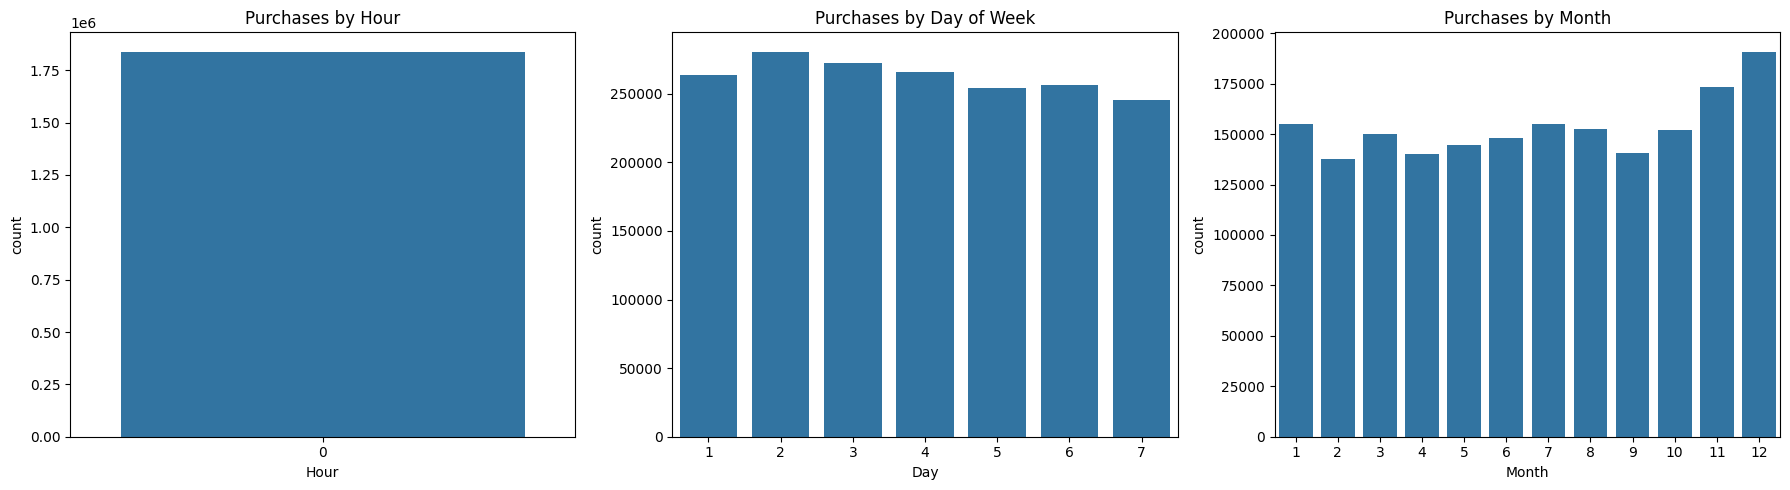

In [40]:
# Purchase Distribution by Hour, Day, and Month

from pyspark.sql.functions import hour, dayofweek, month
import seaborn as sns
import matplotlib.pyplot as plt

# Extract hour, day, and month
time_data = cleaned_data.withColumn(
    "Hour", hour("Order Date")
).withColumn(
    "Day", dayofweek("Order Date")
).withColumn(
    "Month", month("Order Date")
)
# Group and count purchases by time factors
hourly_purchases = time_data.groupBy(
    "Hour"
).count().orderBy("Hour")

daily_purchases = time_data.groupBy(
    "Day"
).count().orderBy("Day")

monthly_purchases = time_data.groupBy(
    "Month"
).count().orderBy("Month")

# Convert to Pandas for visualisation
hourly_pd = hourly_purchases.toPandas()
daily_pd = daily_purchases.toPandas()
monthly_pd = monthly_purchases.toPandas()

# Plot the data
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=hourly_pd,
    x="Hour",
    y="count",
    ax=axes[0]
)
axes[0].set_title("Purchases by Hour")

sns.barplot(
    data=daily_pd,
    x="Day",
    y="count",
    ax=axes[1]
)
axes[1].set_title("Purchases by Day of Week")

sns.barplot(
    data=monthly_pd,
    x="Month",
    y="count",
    ax=axes[2]
)
axes[2].set_title("Purchases by Month")

plt.tight_layout()
plt.show()


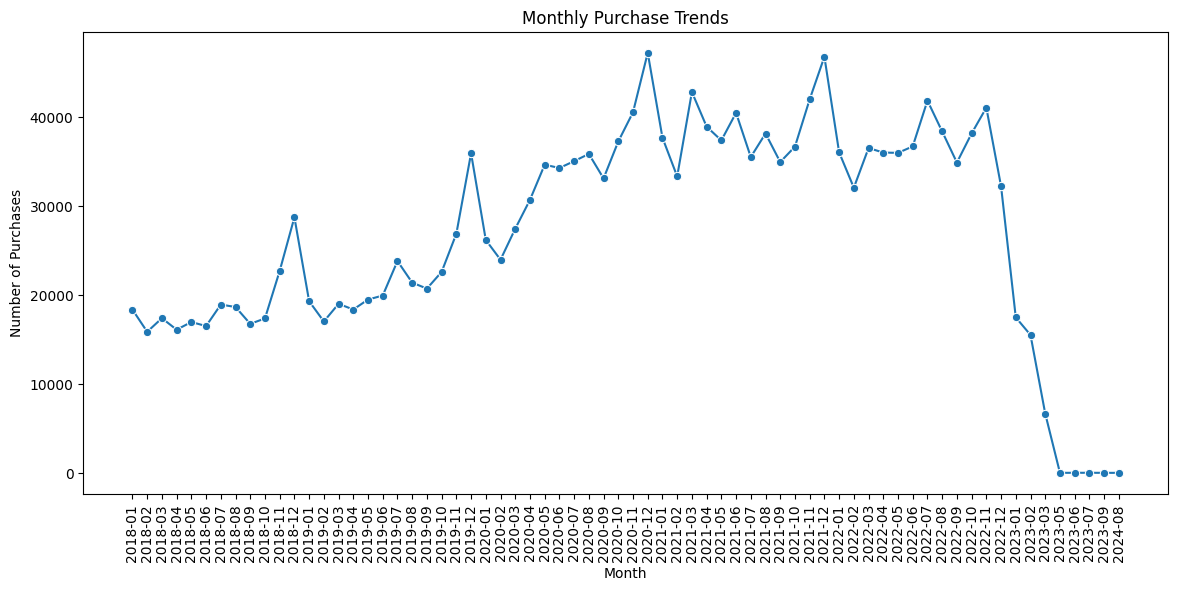

In [41]:
# Monthly Purchase Trends

from pyspark.sql.functions import date_format

# Extract month and year from 'Order Date'
monthly_trend = cleaned_data.withColumn(
    "YearMonth",
    date_format("Order Date", "yyyy-MM")
)

# Group by month and count purchases
monthly_trend = monthly_trend.groupBy(
    "YearMonth"
).count().filter(col("count")>0).orderBy("YearMonth")

# Convert to Pandas for visualisation
monthly_trend_pd = monthly_trend.toPandas()

# Plot
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_trend_pd,
    x="YearMonth",
    y="count",
    marker="o"
)

plt.xticks(rotation=90)
plt.title("Monthly Purchase Trends")
plt.xlabel("Month")
plt.ylabel("Number of Purchases")
plt.show()

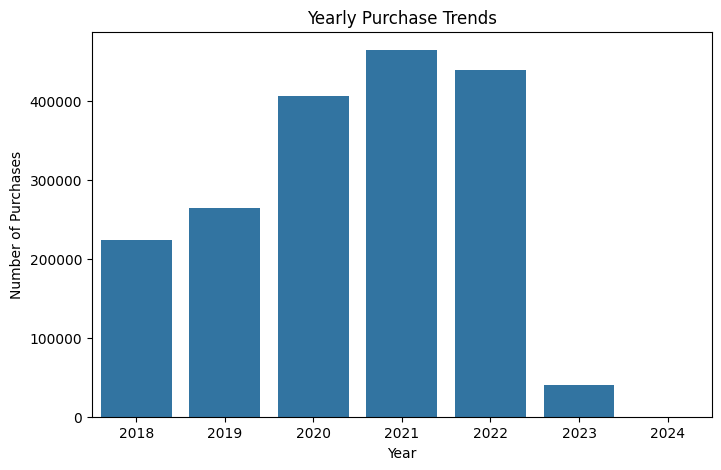

In [42]:
# Yealy Purchase Trends

from pyspark.sql.functions import date_format


# Group by Year and count purchases
yearly_trend = cleaned_data.withColumn(
    "Year",
    date_format("Order Date", "yyyy")
)

yearly_trend = yearly_trend.groupBy(
    "Year"
).count().orderBy("Year")

# Convert to Pandas for visualisation
yearly_trend_pd = yearly_trend.toPandas()

# Plot
plt.figure(figsize=(8,5))

sns.barplot(
    data=yearly_trend_pd,
    x="Year",
    y="count"
)

plt.title("Yearly Purchase Trends")
plt.xlabel("Year")
plt.ylabel("Number of Purchases")
plt.show()

## 3.2 Customer Demographics vs Purchase Frequency <font color = red>[5 marks]</font> <br>
Analyse the trends between the customer deographics and the purchase frequency

In [43]:
# Correlation Between Demographics and Purchase Frequency

from pyspark.sql.functions import count

# Group by demographic attributes and count purchases


# Convert to Pandas for visualisation


# Plot


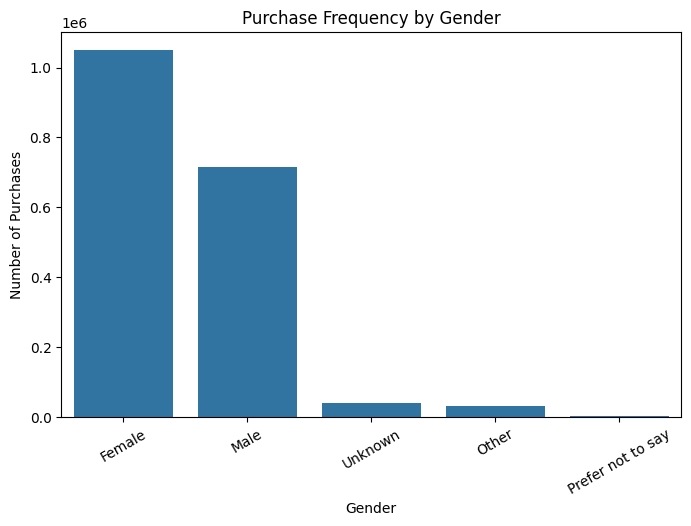

In [44]:
#purchase frequency by gender
from pyspark.sql.functions import count

gender_purchase = (
    cleaned_data
    .groupBy("Q-demos-gender")
    .agg(count("*").alias("Purchase_Count"))
    .orderBy("Purchase_Count", ascending=False)
)

gender_pd = gender_purchase.toPandas()

plt.figure(figsize=(8,5))
sns.barplot(
    data=gender_pd,
    x="Q-demos-gender",
    y="Purchase_Count"
)

plt.title("Purchase Frequency by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=30)
plt.show()

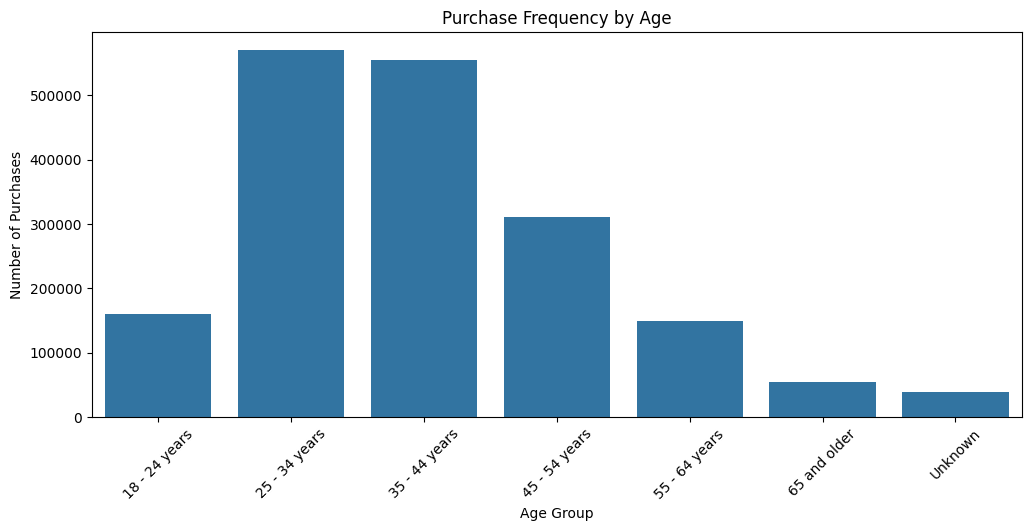

In [45]:
#purchase frequency by age
age_purchase = (
    cleaned_data
    .groupBy("Q-demos-age")
    .agg(count("*").alias("Purchase_Count"))
    .orderBy("Q-demos-age")
)

age_pd = age_purchase.toPandas()

plt.figure(figsize=(12,5))
sns.barplot(
    data=age_pd,
    x="Q-demos-age",
    y="Purchase_Count"
)

plt.title("Purchase Frequency by Age")
plt.xlabel("Age Group")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45)
plt.show()

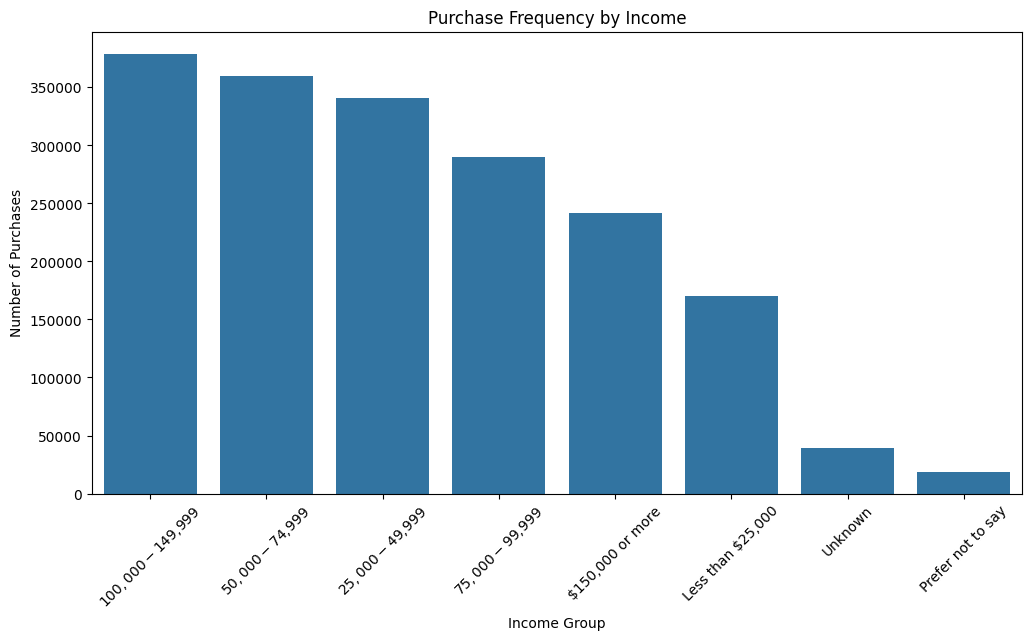

In [46]:
#purchase frequency by income
income_purchase = (
    cleaned_data
    .groupBy("Q-demos-income")
    .agg(count("*").alias("Purchase_Count"))
    .orderBy("Purchase_Count", ascending=False)
)

income_pd = income_purchase.toPandas()

plt.figure(figsize=(12,6))
sns.barplot(
    data=income_pd,
    x="Q-demos-income",
    y="Purchase_Count"
)

plt.title("Purchase Frequency by Income")
plt.xlabel("Income Group")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45)
plt.show()

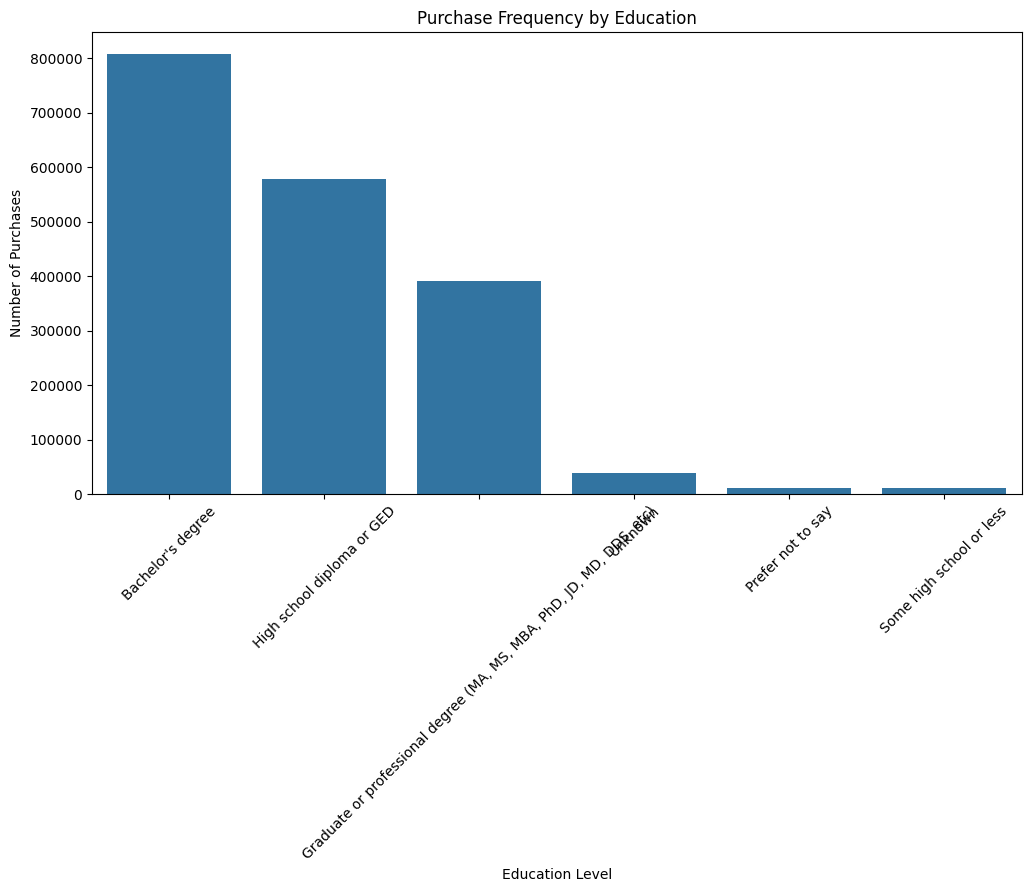

In [47]:
#purchase frequency by education
education_purchase = (
    cleaned_data
    .groupBy("Q-demos-education")
    .agg(count("*").alias("Purchase_Count"))
    .orderBy("Purchase_Count", ascending=False)
)

education_pd = education_purchase.toPandas()

plt.figure(figsize=(12,6))
sns.barplot(
    data=education_pd,
    x="Q-demos-education",
    y="Purchase_Count"
)

plt.title("Purchase Frequency by Education")
plt.xlabel("Education Level")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45)
plt.show()

## 3.3 Purchase behavior weekend vs weekday <font color = red>[5 marks]</font> <br>

Compare the purchase behavior of customer's on weekdays vs. weekends.

  Purchase_Type    count
0       Weekday  1329624
1       Weekend   509398


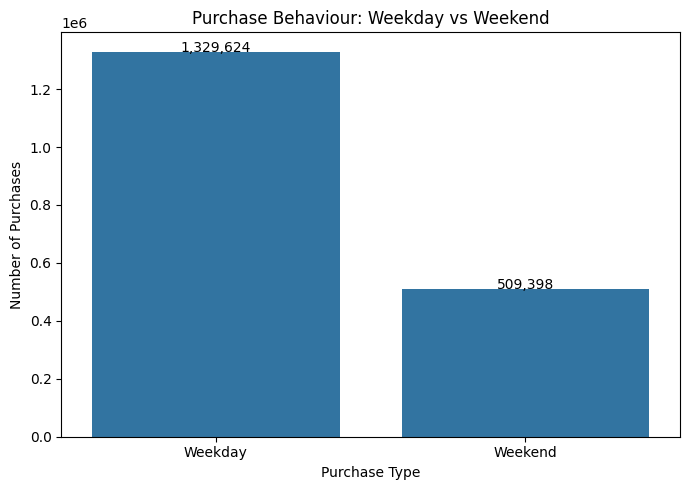

In [48]:
from pyspark.sql.functions import when, dayofweek
import seaborn as sns
import matplotlib.pyplot as plt

# Define weekdays and weekends
weekend_data = cleaned_data.withColumn(
    "Purchase_Type",
    when(
        dayofweek("Order Date").isin([1, 7]),
        "Weekend"
    ).otherwise("Weekday")
)

# Group and count purchases
purchase_behavior = (
    weekend_data
    .groupBy("Purchase_Type")
    .count()
    .orderBy("Purchase_Type")
)

# Convert to Pandas for visualisation
purchase_behavior_pd = purchase_behavior.toPandas()

# Display counts
print(purchase_behavior_pd)

# Plot
plt.figure(figsize=(7,5))

sns.barplot(
    data=purchase_behavior_pd,
    x="Purchase_Type",
    y="count"
)

plt.title("Purchase Behaviour: Weekday vs Weekend")
plt.xlabel("Purchase Type")
plt.ylabel("Number of Purchases")

for i, v in enumerate(purchase_behavior_pd["count"]):
    plt.text(i, v, f"{v:,}", ha='center')

plt.tight_layout()
plt.show()

In [49]:
purchase_behavior_pd["Percentage"] = (
    purchase_behavior_pd["count"]
    / purchase_behavior_pd["count"].sum()
) * 100

print(purchase_behavior_pd)

  Purchase_Type    count  Percentage
0       Weekday  1329624   72.300603
1       Weekend   509398   27.699397


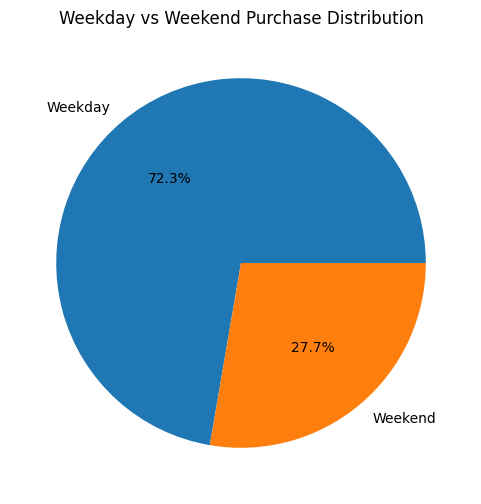

In [50]:
plt.figure(figsize=(6,6))

plt.pie(
    purchase_behavior_pd["count"],
    labels=purchase_behavior_pd["Purchase_Type"],
    autopct='%1.1f%%'
)

plt.title("Weekday vs Weekend Purchase Distribution")
plt.show()

## 3.4 Frequently purchased product pairs <font color = red>[5 marks]</font> <br>

Analyze how frequently products are purchased together (also known as Market Basket Analysis)


In [51]:
cleaned_data.columns

['Survey ResponseID',
 'Order Date',
 'Purchase Price Per Unit',
 'Quantity',
 'Shipping Address State',
 'Title',
 'ASIN/ISBN (Product Code)',
 'Category',
 'Q-demos-age',
 'Q-demos-hispanic',
 'Q-demos-race',
 'Q-demos-education',
 'Q-demos-income',
 'Q-demos-gender',
 'Q-sexual-orientation',
 'Q-demos-state',
 'Q-amazon-use-howmany',
 'Q-amazon-use-hh-size',
 'Q-amazon-use-how-oft',
 'Q-substance-use-cigarettes',
 'Q-substance-use-marijuana',
 'Q-substance-use-alcohol',
 'Q-personal-diabetes',
 'Q-personal-wheelchair',
 'Q-life-changes',
 'Q-sell-YOUR-data',
 'Q-sell-consumer-data',
 'Q-small-biz-use',
 'Q-census-use',
 'Q-research-society',
 'Order_Date',
 'Order_Month',
 'Order_Year',
 'Income_Numeric',
 'Gender_Numeric']

In [52]:
# Frequently Purchased Product Pairs (Market Basket Analysis)

from pyspark.sql.functions import collect_set, explode

# Group purchases by customer and collect items bought together


# Explode item pairs


# Count co-occurrences of items


# Convert to Pandas for visualisation


# Plot

In [53]:
sample_data = cleaned_data.sample(False, 0.05, seed=42)

In [54]:
from pyspark.sql.functions import size

basket = (
    sample_data
    .groupBy("Survey ResponseID")
    .agg(collect_set("Title").alias("Items"))
    .filter(size("Items") > 1)
)

In [55]:
#generating product pairs
from itertools import combinations

pair_list = []

for row in basket.toLocalIterator():
    items = row["Items"]

    for pair in combinations(sorted(items), 2):
        pair_list.append(pair)

In [56]:
#creating spark dataframe of pairs
pair_df = spark.createDataFrame(
    pair_list,
    ["Product1", "Product2"]
)

In [57]:
#counting co-occurences
pair_counts = (
    pair_df
    .groupBy("Product1", "Product2")
    .count()
    .orderBy("count", ascending=False)
)

In [58]:
#top pairs
pair_counts.show(10, truncate=False)

+----------------------------------------------------------------------------------------------------------+-----------------------------------+-----+
|Product1                                                                                                  |Product2                           |count|
+----------------------------------------------------------------------------------------------------------+-----------------------------------+-----+
|Amazon.com Gift Card Balance Reload                                                                       |Unknown                            |154  |
|Amazon.com eGift Card                                                                                     |Unknown                            |98   |
|Amazon Reload                                                                                             |Unknown                            |97   |
|Amazon Reload                                                                                

In [62]:
#creating labels
top_pairs_pd = (
    pair_counts
    .limit(10)
    .toPandas()
)

In [63]:
print(top_pairs_pd.shape)
top_pairs_pd.head()


(10, 3)


,Product1,Product2,count
0,Amazon.com Gift Card Balance Reload,Unknown,154
1,Amazon.com eGift Card,Unknown,98
2,Amazon Reload,Unknown,97
3,Amazon Reload,Amazon.com Gift Card Balance Reload,44
4,Amazon Basics 36 Pack AAA High-Performance Alk...,Unknown,27


In [64]:
print(top_pairs_pd.columns)

Index(['Product1', 'Product2', 'count'], dtype='object')


In [65]:
top_pairs_pd["Product_Pair"] = (
    top_pairs_pd["Product1"].astype(str)
    + " + " +
    top_pairs_pd["Product2"].astype(str)
)

In [66]:
top_pairs_pd.head()

,Product1,Product2,count,Product_Pair
0,Amazon.com Gift Card Balance Reload,Unknown,154,Amazon.com Gift Card Balance Reload + Unknown
1,Amazon.com eGift Card,Unknown,98,Amazon.com eGift Card + Unknown
2,Amazon Reload,Unknown,97,Amazon Reload + Unknown
3,Amazon Reload,Amazon.com Gift Card Balance Reload,44,Amazon Reload + Amazon.com Gift Card Balance R...
4,Amazon Basics 36 Pack AAA High-Performance Alk...,Unknown,27,Amazon Basics 36 Pack AAA High-Performance Alk...


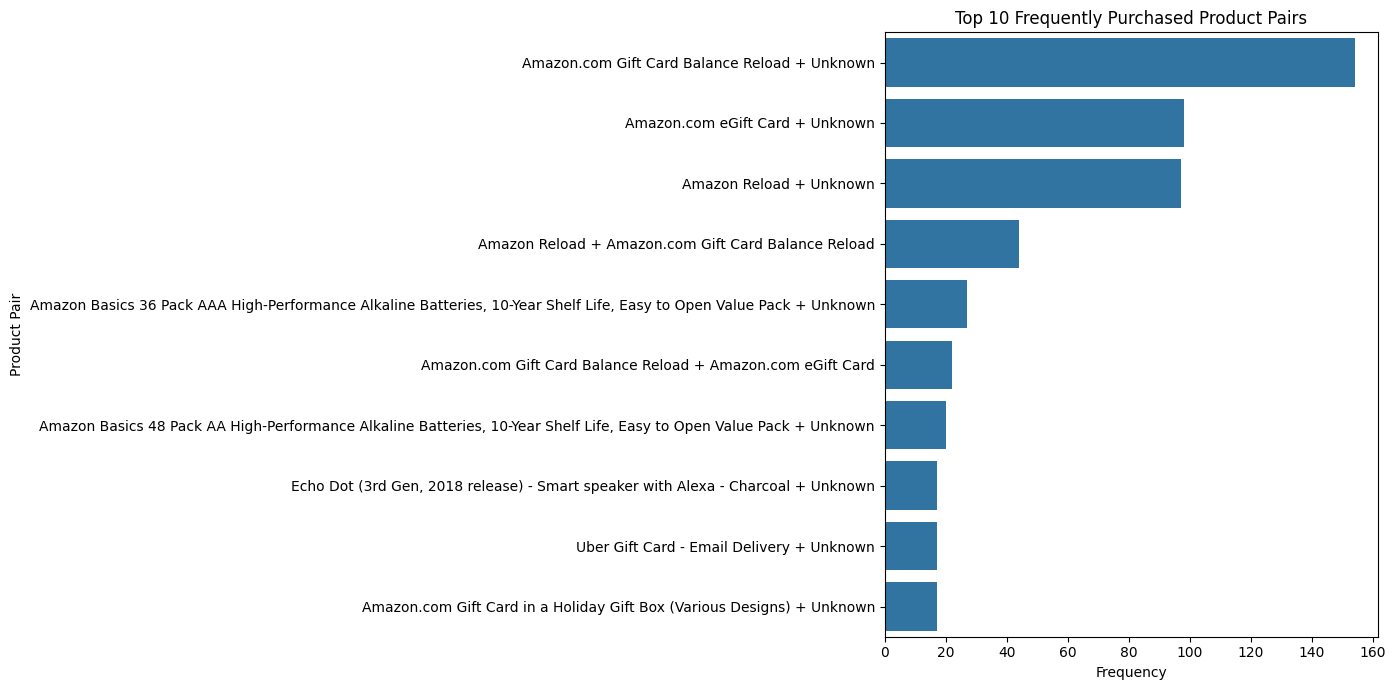

In [67]:
#plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

sns.barplot(
    data=top_pairs_pd,
    y="Product_Pair",
    x="count"
)

plt.title("Top 10 Frequently Purchased Product Pairs")
plt.xlabel("Frequency")
plt.ylabel("Product Pair")

plt.tight_layout()
plt.show()

## 3.5 Examine Product Performance <font color = red>[5 marks]</font> <br>

Examine the performance of products by calculating revenue and item popularity.

In [ ]:
# Contribution of Product Categories (Top 25)



# Convert to Pandas for visualisation


# Plot

In [68]:
from pyspark.sql.functions import col

cleaned_data = cleaned_data.withColumn(
    "Revenue",
    col("Purchase Price Per Unit") * col("Quantity")
)

In [69]:
# top 25 categories by revenue
from pyspark.sql.functions import sum as spark_sum

category_revenue = (
    cleaned_data
    .groupBy("Category")
    .agg(
        spark_sum("Revenue").alias("Total_Revenue")
    )
    .orderBy(
        col("Total_Revenue").desc()
    )
    .limit(25)
)

In [70]:
category_revenue_pd = category_revenue.toPandas()

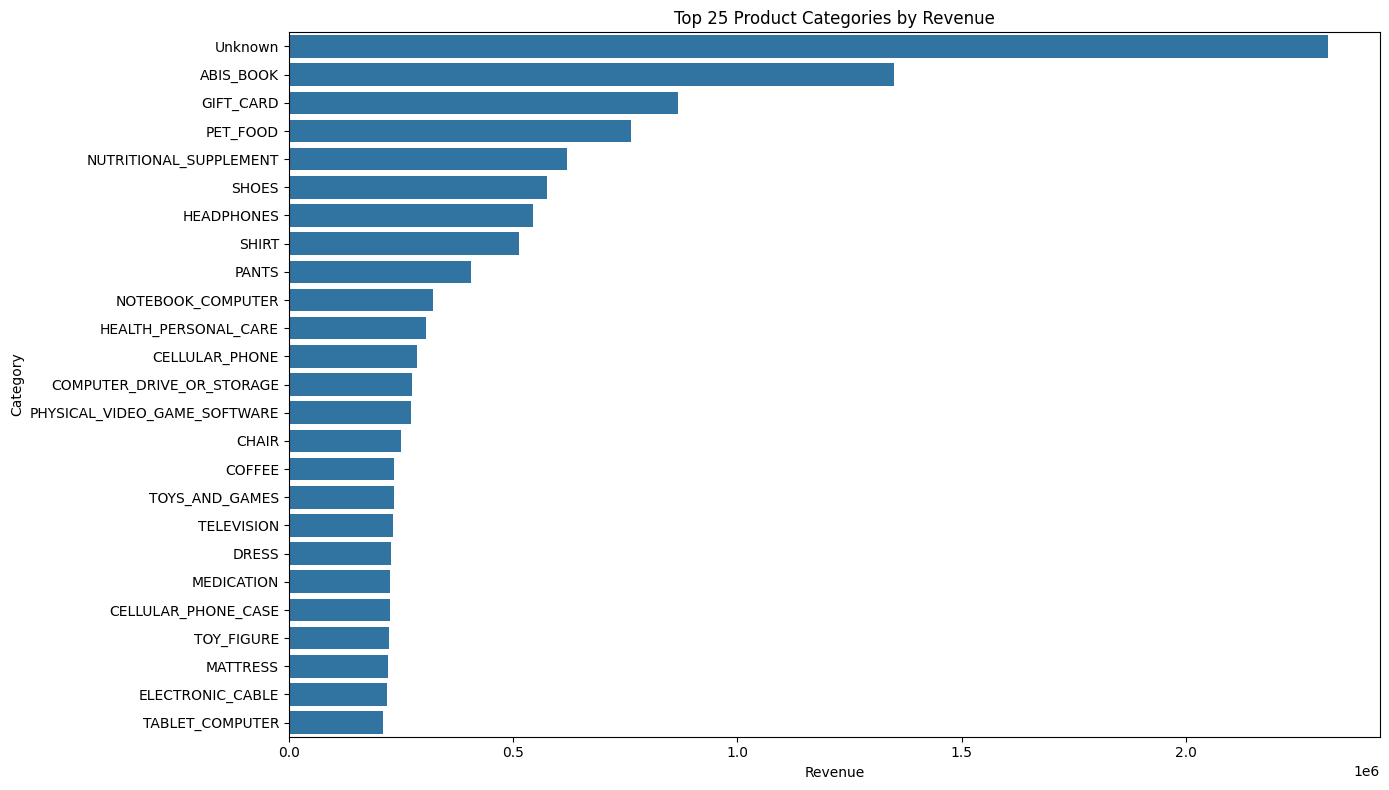

In [71]:
#plot
plt.figure(figsize=(14,8))

sns.barplot(
    data=category_revenue_pd,
    y="Category",
    x="Total_Revenue"
)

plt.title("Top 25 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [72]:
# top 25 by popularity
category_popularity = (
    cleaned_data
    .groupBy("Category")
    .agg(
        spark_sum("Quantity").alias("Items_Sold")
    )
    .orderBy(
        col("Items_Sold").desc()
    )
    .limit(25)
)

In [73]:
category_popularity_pd = category_popularity.toPandas()

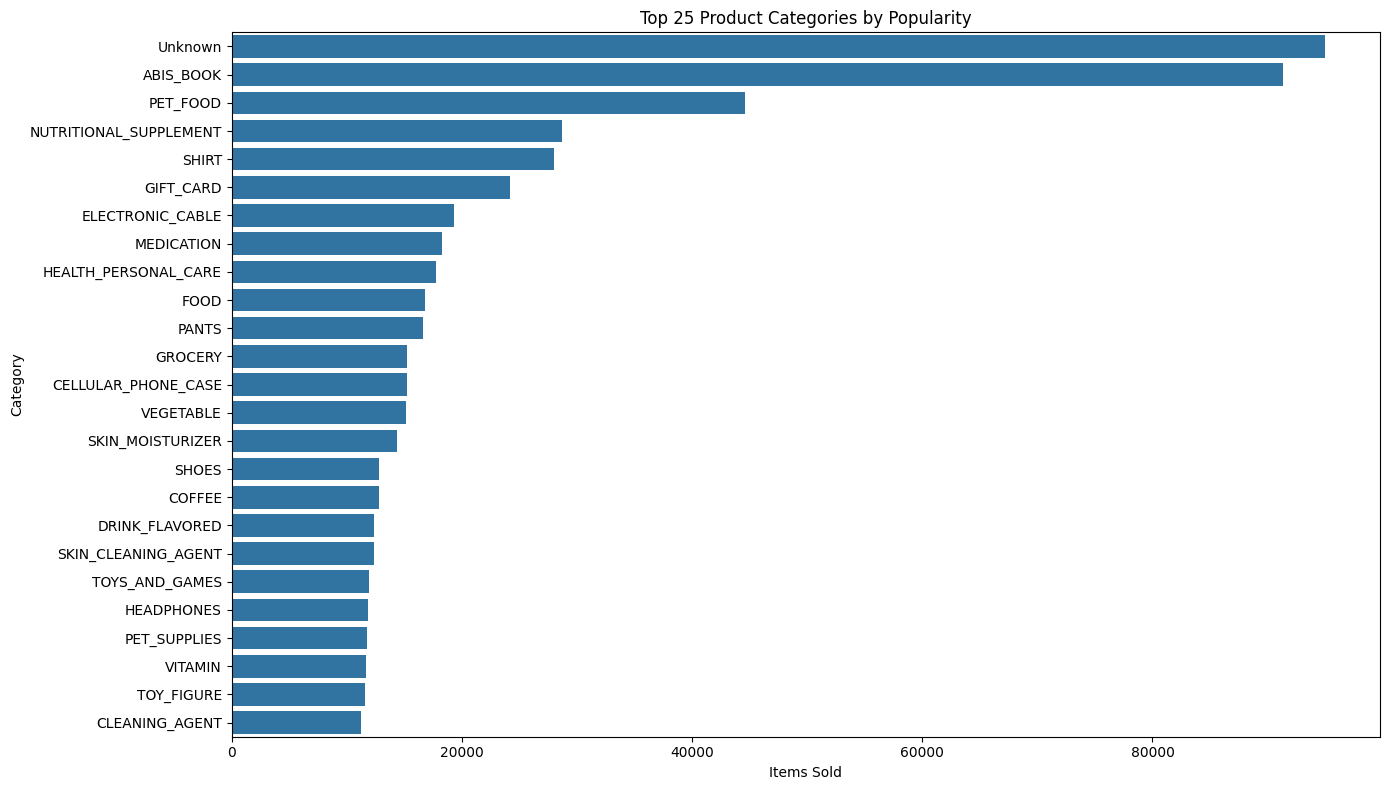

In [74]:
#plot
plt.figure(figsize=(14,8))

sns.barplot(
    data=category_popularity_pd,
    y="Category",
    x="Items_Sold"
)

plt.title("Top 25 Product Categories by Popularity")
plt.xlabel("Items Sold")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

## 3.6 Top products by quantity <font color = red>[5 marks]</font> <br>

Identify the most frequently purchased products.

+----------------------------------------------------------------------------------------+--------------+
|Title                                                                                   |Total_Quantity|
+----------------------------------------------------------------------------------------+--------------+
|Unknown                                                                                 |95254.0       |
|Amazon.com Gift Card Balance Reload                                                     |8282.0        |
|Amazon.com eGift Card                                                                   |5179.0        |
|Amazon Reload                                                                           |4876.0        |
|Photo Prints – Glossy – Standard Size (4x6)                                             |2336.0        |
|Photo Prints – Glossy – Standard Size (4x5.3)                                           |1833.0        |
|Google Play gift code - give the gift of game

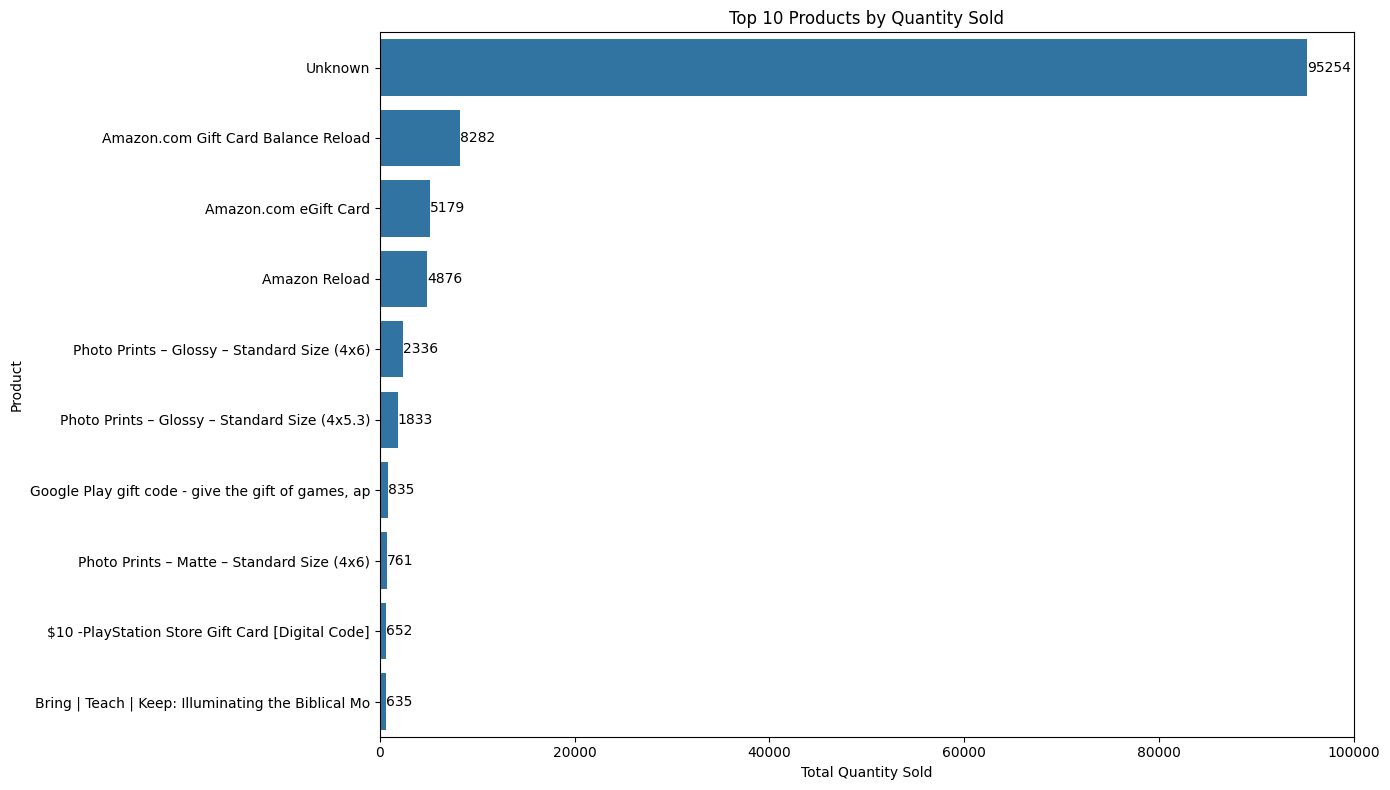

In [75]:
# Top 10 Products by Quantity

# Group by product title and sum 'Quantity'
from pyspark.sql.functions import sum as spark_sum, col

top_products_quantity = (
    cleaned_data
    .groupBy("Title")
    .agg(
        spark_sum("Quantity").alias("Total_Quantity")
    )
    .orderBy(
        col("Total_Quantity").desc()
    )
    .limit(10)
)

top_products_quantity.show(truncate=False)
# Convert to Pandas for visualisation
top_products_pd = top_products_quantity.toPandas()

top_products_pd["Short_Title"] = (
    top_products_pd["Title"]
    .str.slice(0, 50)
)
# Plot

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,8))

ax = sns.barplot(
    data=top_products_pd,
    y="Short_Title",
    x="Total_Quantity"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

## 3.7 Distribution of Purchases by State <font color = red>[5 marks]</font> <br>

Analyze the distribution of purchases across states and categories.

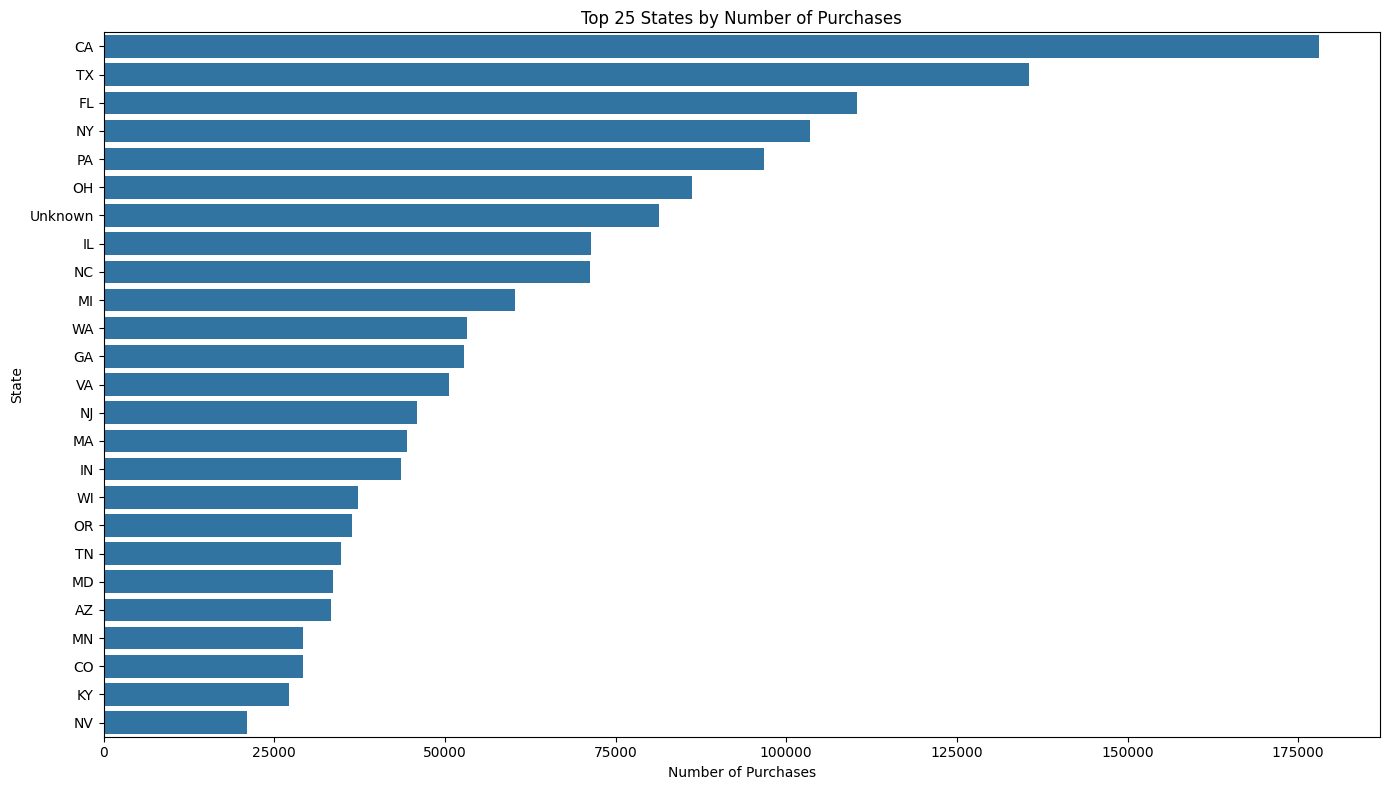

In [77]:
# Distribution of Purchases by State (Top 25)
from pyspark.sql.functions import count, col

state_distribution = (
    cleaned_data
    .groupBy("Shipping Address State")
    .agg(
        count("*").alias("Purchase_Count")
    )
    .orderBy(
        col("Purchase_Count").desc()
    )
    .limit(25)
)

# Convert to Pandas for visualisation
state_distribution_pd = state_distribution.toPandas()

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,8))

sns.barplot(
    data=state_distribution_pd,
    y="Shipping Address State",
    x="Purchase_Count"
)

plt.title("Top 25 States by Number of Purchases")
plt.xlabel("Number of Purchases")
plt.ylabel("State")

plt.tight_layout()
plt.show()

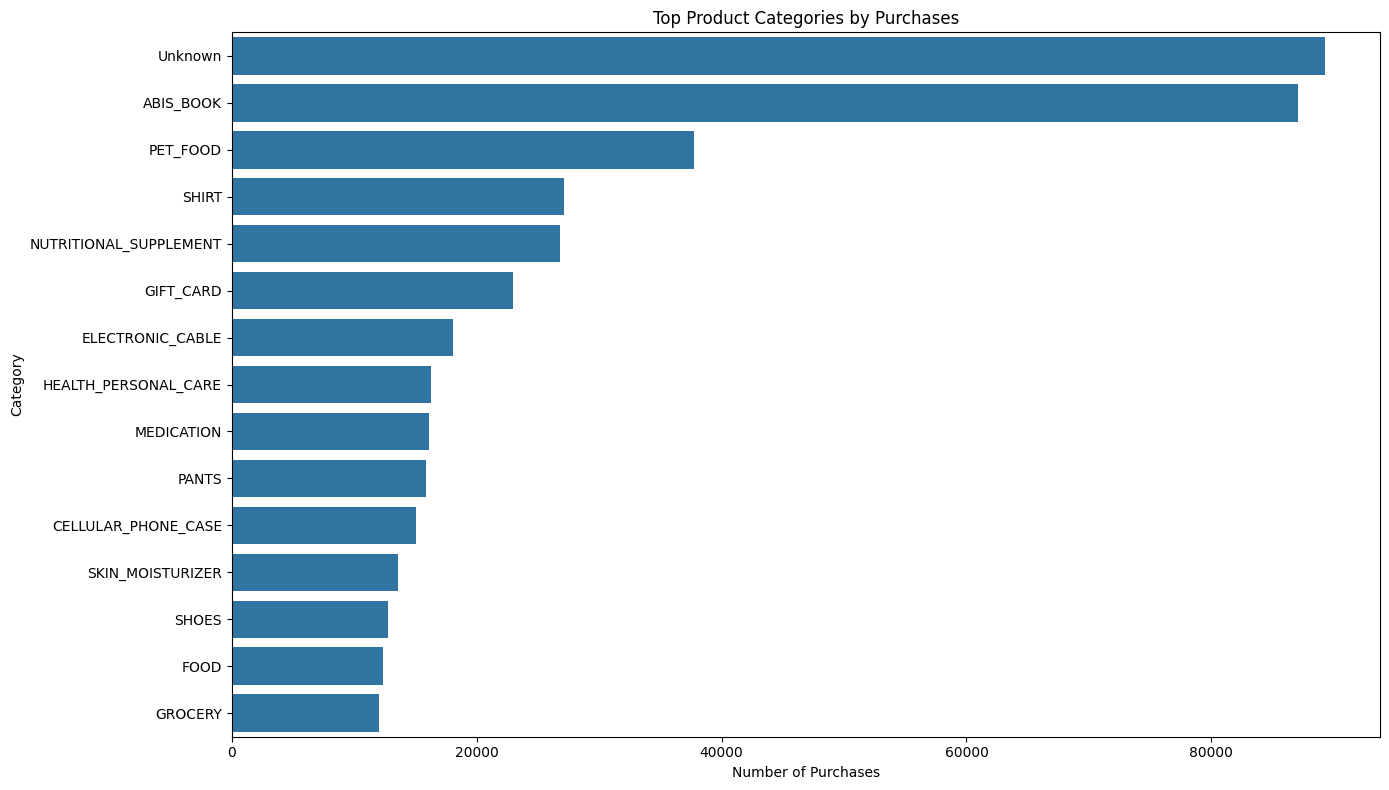

In [79]:
#Distribution of purchases by category
category_distribution = (
    cleaned_data
    .groupBy("Category")
    .agg(
        count("*").alias("Purchase_Count")
    )
    .orderBy(
        col("Purchase_Count").desc()
    )
    .limit(15)
)
category_distribution_pd = category_distribution.toPandas()
plt.figure(figsize=(14,8))

sns.barplot(
    data=category_distribution_pd,
    y="Category",
    x="Purchase_Count"
)

plt.title("Top Product Categories by Purchases")
plt.xlabel("Number of Purchases")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

## 3.8 Price vs Product Quantity <font color = red>[5 marks]</font> <br>

Identify the Relationship between Price and Quantity

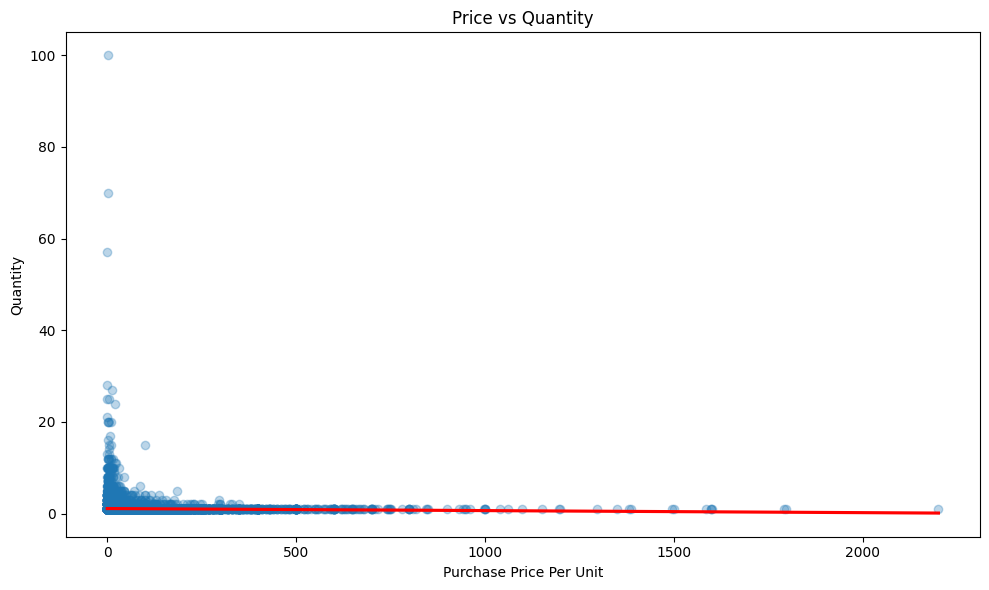

In [80]:
# Relationship Between Price and Quantity
price_quantity = cleaned_data.select(
    "Purchase Price Per Unit",
    "Quantity"
)
price_quantity_sample = price_quantity.sample(
    False,
    0.05,
    seed=42
)
# Convert to Pandas for visualisation
price_quantity_pd = (
    price_quantity_sample
    .toPandas()
)

price_quantity_pd = price_quantity_pd.dropna()

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.regplot(
    data=price_quantity_pd,
    x="Purchase Price Per Unit",
    y="Quantity",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

plt.title("Price vs Quantity")
plt.xlabel("Purchase Price Per Unit")
plt.ylabel("Quantity")

plt.tight_layout()
plt.show()

In [81]:
#correlation
correlation = price_quantity_pd[
    ["Purchase Price Per Unit", "Quantity"]
].corr()

print(correlation)

                         Purchase Price Per Unit  Quantity
Purchase Price Per Unit                 1.000000 -0.029515
Quantity                               -0.029515  1.000000


## 3.9 Analyse the spending KPIs <font color = red>[5 marks]</font> <br>


A popular KPI is average spend per customer. Calculate this metric as the ratio of total transaction amount from non-recurring payments divided by the total number of customers who made a purchase

Average Spend per Customer: 2745.78


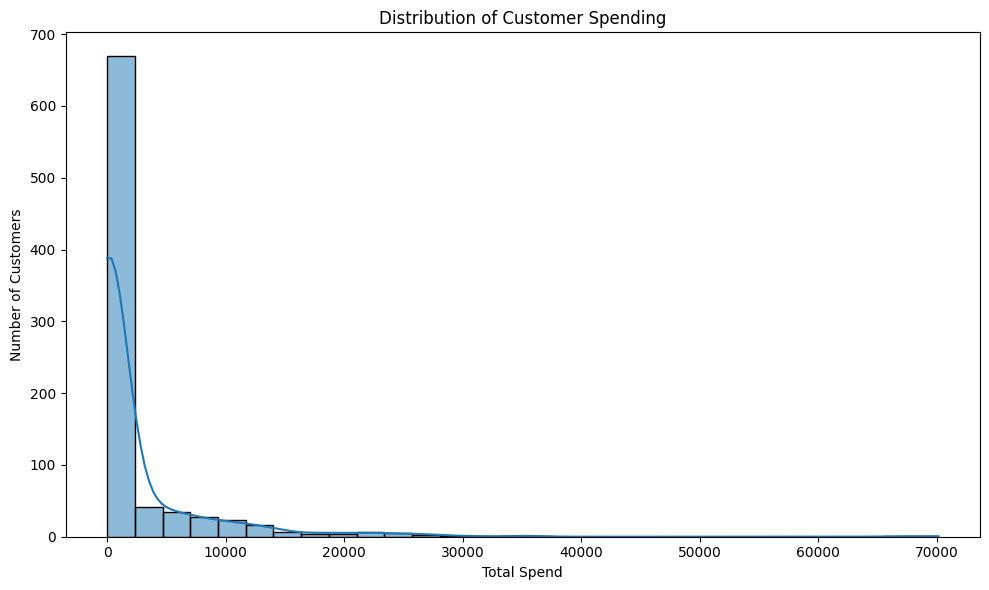

In [83]:
# Average Spend per Customer

from pyspark.sql.functions import avg

# Group by customer and calculate average spend
from pyspark.sql.functions import col

cleaned_data = cleaned_data.withColumn(
    "Revenue",
    col("Purchase Price Per Unit") * col("Quantity")
)
#calculating spend per customer
from pyspark.sql.functions import sum as spark_sum

customer_spend = (
    cleaned_data
    .groupBy("Survey ResponseID")
    .agg(
        spark_sum("Revenue").alias("Total_Spend")
    )
)

#calculating average spend
average_spend = customer_spend.agg(
    avg("Total_Spend")
).collect()[0][0]

print("Average Spend per Customer:", round(average_spend, 2))
# Convert to Pandas for visualisation
customer_spend_pd = (
    customer_spend
    .sample(False, 0.05, seed=42)
    .toPandas()
)

# Plot
plt.figure(figsize=(10,6))

sns.histplot(
    customer_spend_pd["Total_Spend"],
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Spending")
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Analyse the Repeat Purchase Behavior of Customers

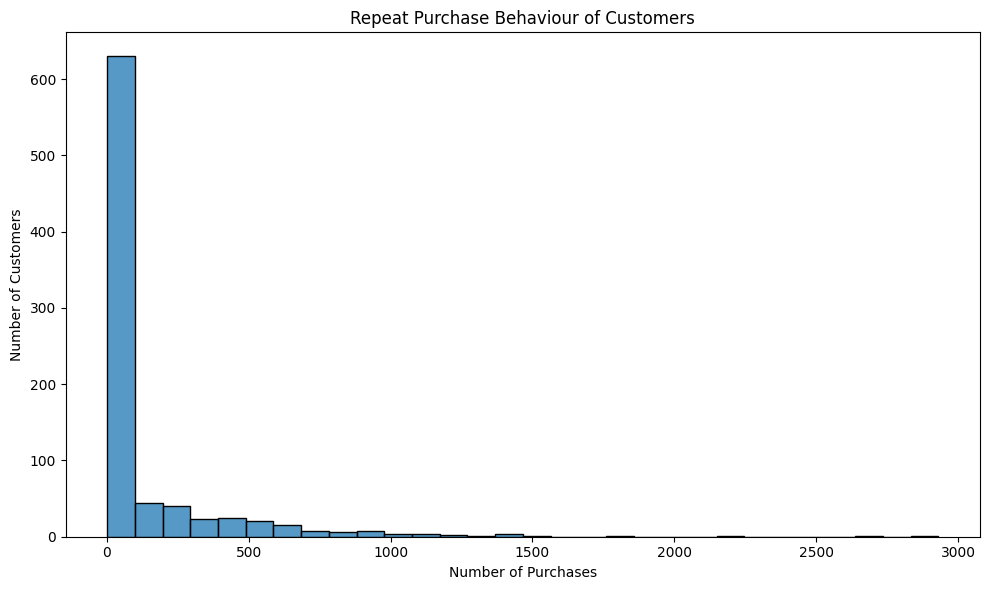

In [84]:
# Repeat Purchase Analysis Behavior Per Customers
repeat_purchase = (
    cleaned_data
    .groupBy("Survey ResponseID")
    .count()
    .withColumnRenamed(
        "count",
        "Number_of_Purchases"
    )
)

# Convert to Pandas for visualisation
repeat_purchase_pd = (
    repeat_purchase
    .sample(False, 0.05, seed=42)
    .toPandas()
)

# Plot
plt.figure(figsize=(10,6))

sns.histplot(
    repeat_purchase_pd["Number_of_Purchases"],
    bins=30
)

plt.title("Repeat Purchase Behaviour of Customers")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Analyse the top 10 high-engagement customers

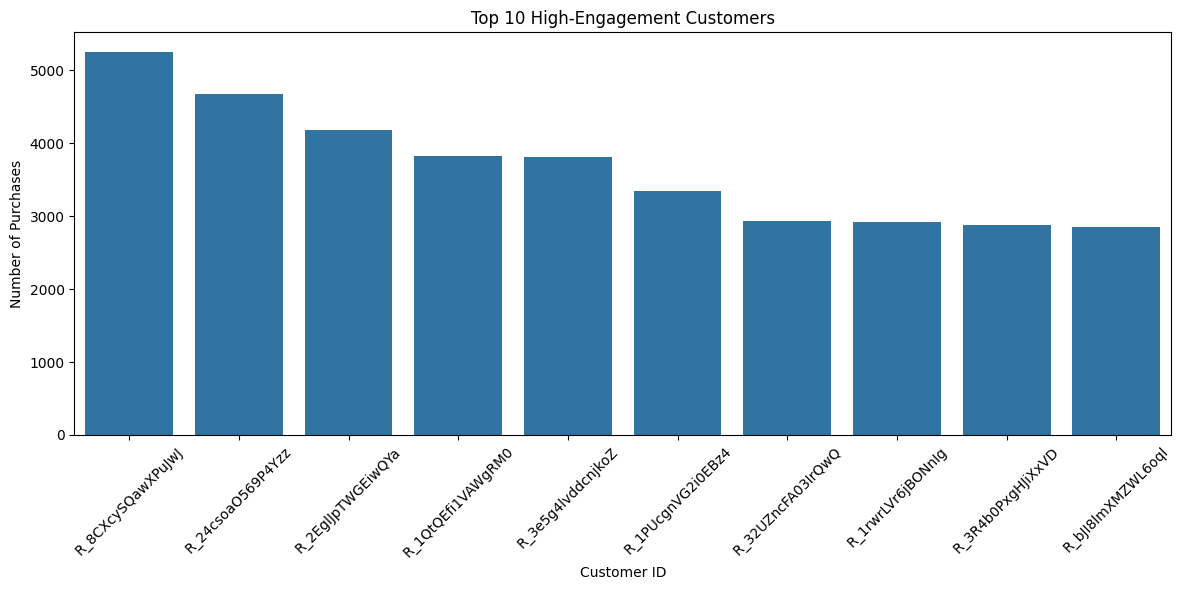

In [85]:
# Top 10 High-Engagement Customers
top_customers = (
    cleaned_data
    .groupBy("Survey ResponseID")
    .count()
    .withColumnRenamed(
        "count",
        "Purchase_Count"
    )
    .orderBy(
        col("Purchase_Count").desc()
    )
    .limit(10)
)

# Convert to Pandas for visualisation
top_customers_pd = top_customers.toPandas()

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_customers_pd,
    x="Survey ResponseID",
    y="Purchase_Count"
)

plt.title("Top 10 High-Engagement Customers")
plt.xlabel("Customer ID")
plt.ylabel("Number of Purchases")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [86]:
top_customers_pd

,Survey ResponseID,Purchase_Count
0,R_8CXcySQawXPuJwJ,5258
1,R_24csoaO569P4Yzz,4675
2,R_2EglJpTWGEiwQYa,4185
3,R_1QtQEfi1VAWgRM0,3825
4,R_3e5g4lvddcnjkoZ,3815
5,R_1PUcgnVG2i0EBz4,3339
6,R_32UZncFA03IrQwQ,2931
7,R_1rwrLVr6jBONnIg,2923
8,R_3R4b0PxgHJiXxVD,2875
9,R_bJI8lmXMZWL6oql,2856


## 3.10 Seasonal trends in product purchases and their impact on revenues <font color = red>[5 marks]</font> <br>

Investigate the seasonal trends in product purchases and their impact on the overall revenue.

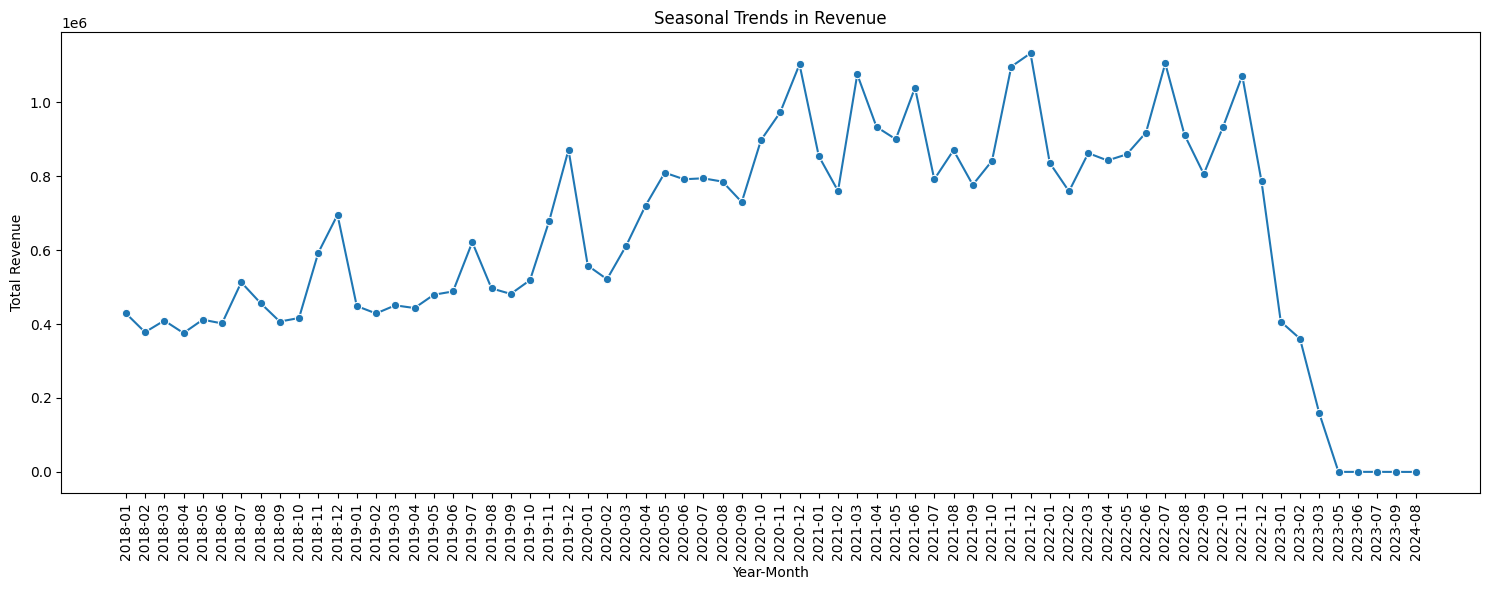

In [87]:
# Seasonal Trends in Product Purchases and Their Impact on Revenue

from pyspark.sql.functions import year

# Extract year and month
from pyspark.sql.functions import year, month

seasonal_data = (
    cleaned_data
    .withColumn(
        "Year",
        year("Order Date")
    )
    .withColumn(
        "Month",
        month("Order Date")
    )
)

# Group by year and month, summing total revenue
from pyspark.sql.functions import sum as spark_sum

monthly_revenue = (
    seasonal_data
    .groupBy("Year", "Month")
    .agg(
        spark_sum("Revenue").alias("Total_Revenue")
    )
    .orderBy("Year", "Month")
)

# Convert to Pandas for visualisation
monthly_revenue_pd = monthly_revenue.toPandas()

monthly_revenue_pd["Year_Month"] = (
    monthly_revenue_pd["Year"].astype(str)
    + "-"
    + monthly_revenue_pd["Month"].astype(str).str.zfill(2)
)

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,6))

sns.lineplot(
    data=monthly_revenue_pd,
    x="Year_Month",
    y="Total_Revenue",
    marker="o"
)

plt.title("Seasonal Trends in Revenue")
plt.xlabel("Year-Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

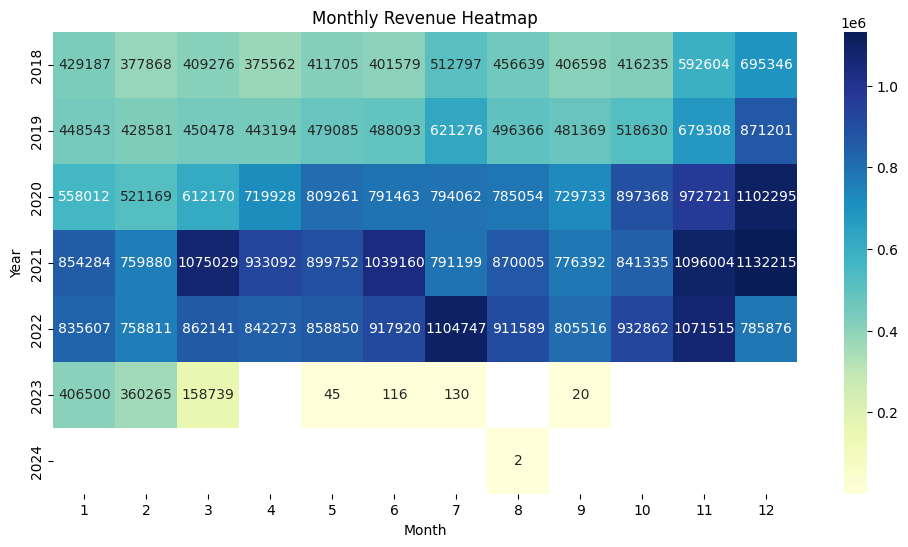

In [88]:
#heatmap
pivot_revenue = monthly_revenue_pd.pivot(
    index="Year",
    columns="Month",
    values="Total_Revenue"
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot_revenue,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Monthly Revenue Heatmap")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

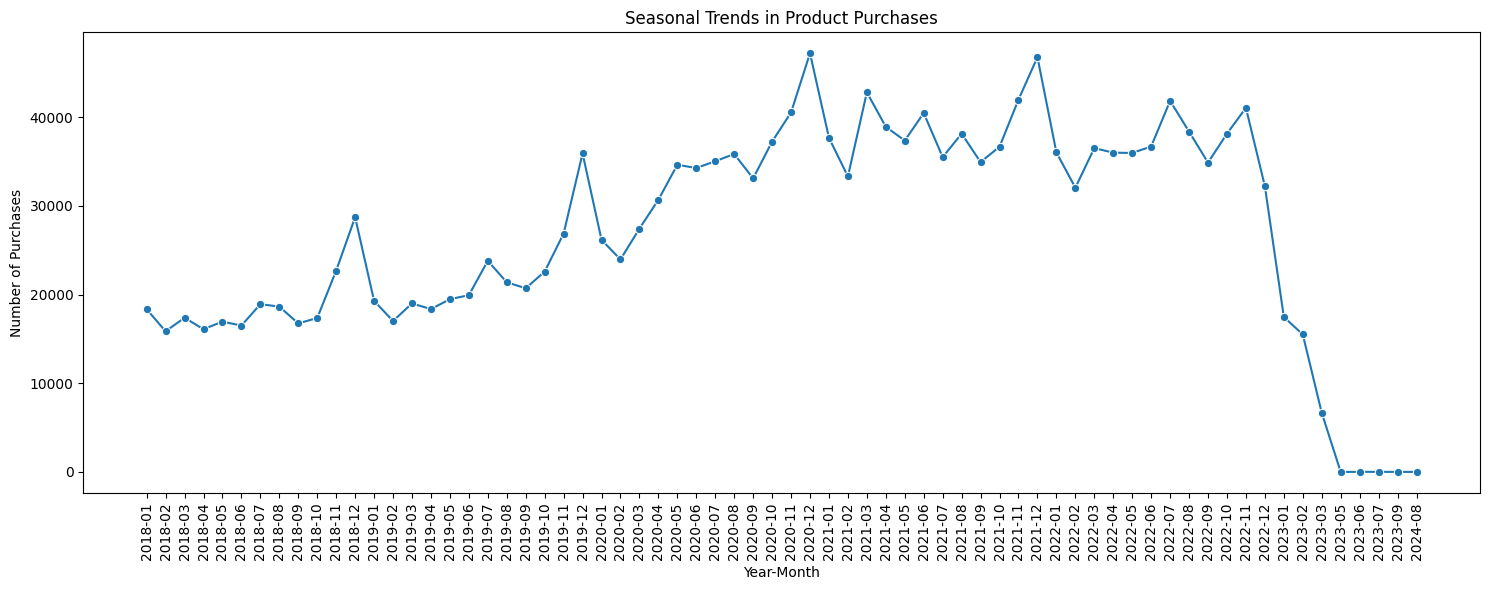

In [89]:
#seasonal product purchases
monthly_orders = (
    seasonal_data
    .groupBy("Year", "Month")
    .count()
    .orderBy("Year", "Month")
)

monthly_orders_pd = monthly_orders.toPandas()

monthly_orders_pd["Year_Month"] = (
    monthly_orders_pd["Year"].astype(str)
    + "-"
    + monthly_orders_pd["Month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(15,6))

sns.lineplot(
    data=monthly_orders_pd,
    x="Year_Month",
    y="count",
    marker="o"
)

plt.title("Seasonal Trends in Product Purchases")
plt.xlabel("Year-Month")
plt.ylabel("Number of Purchases")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 3.11 Customer location vs purchasing behavior <font color = red>[5 marks]</font> <br>

Examine the relationship between customer's location and their purchasing behaviors

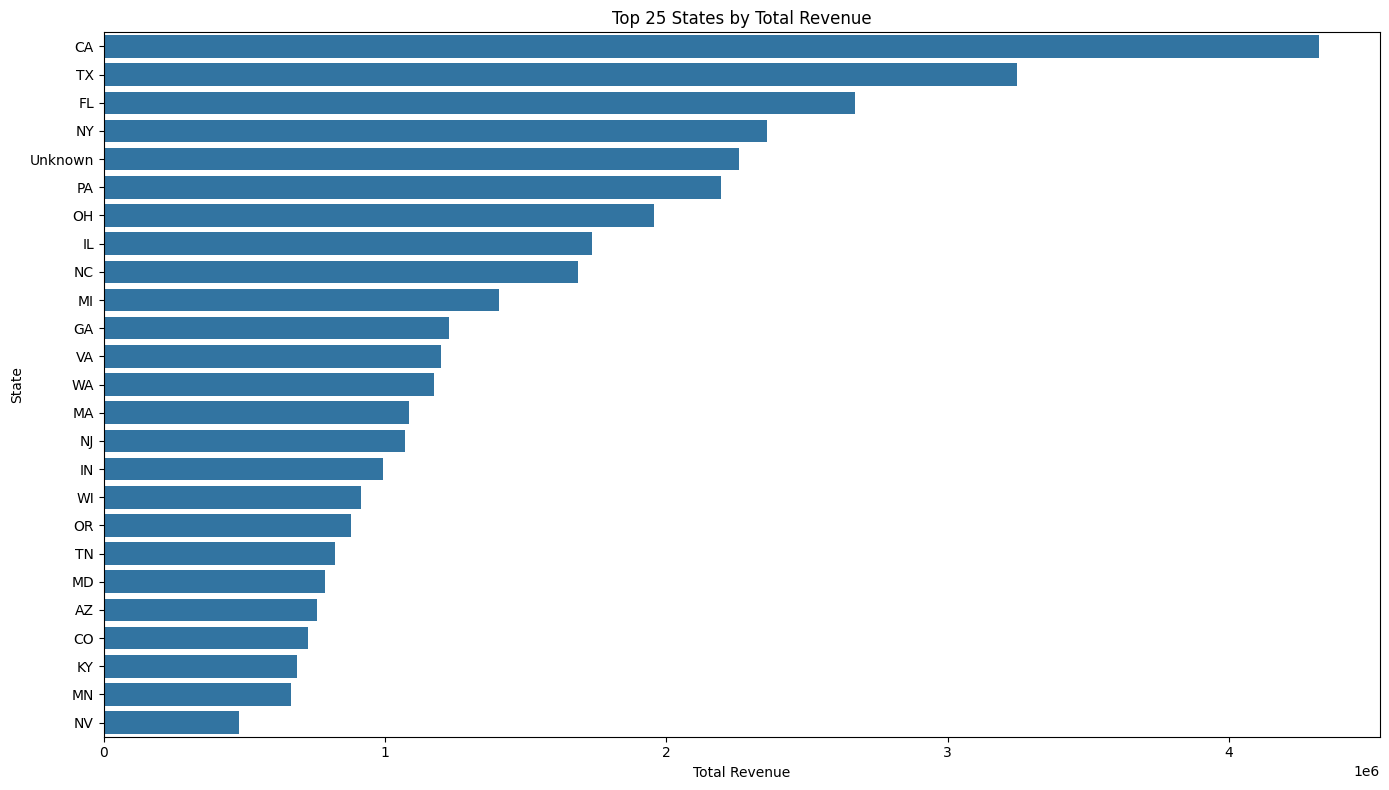

In [90]:
# Relationship Between Customer Location and Purchase Behavior

# Group purchases by state and total spend
from pyspark.sql.functions import sum as spark_sum, col

state_revenue = (
    cleaned_data
    .groupBy("Shipping Address State")
    .agg(
        spark_sum("Revenue").alias("Total_Revenue")
    )
    .orderBy(
        col("Total_Revenue").desc()
    )
    .limit(25)
)

# Convert to Pandas for visualisation
state_revenue_pd = state_revenue.toPandas()

# Plot revenue by state
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,8))

sns.barplot(
    data=state_revenue_pd,
    y="Shipping Address State",
    x="Total_Revenue"
)

plt.title("Top 25 States by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("State")

plt.tight_layout()
plt.show()

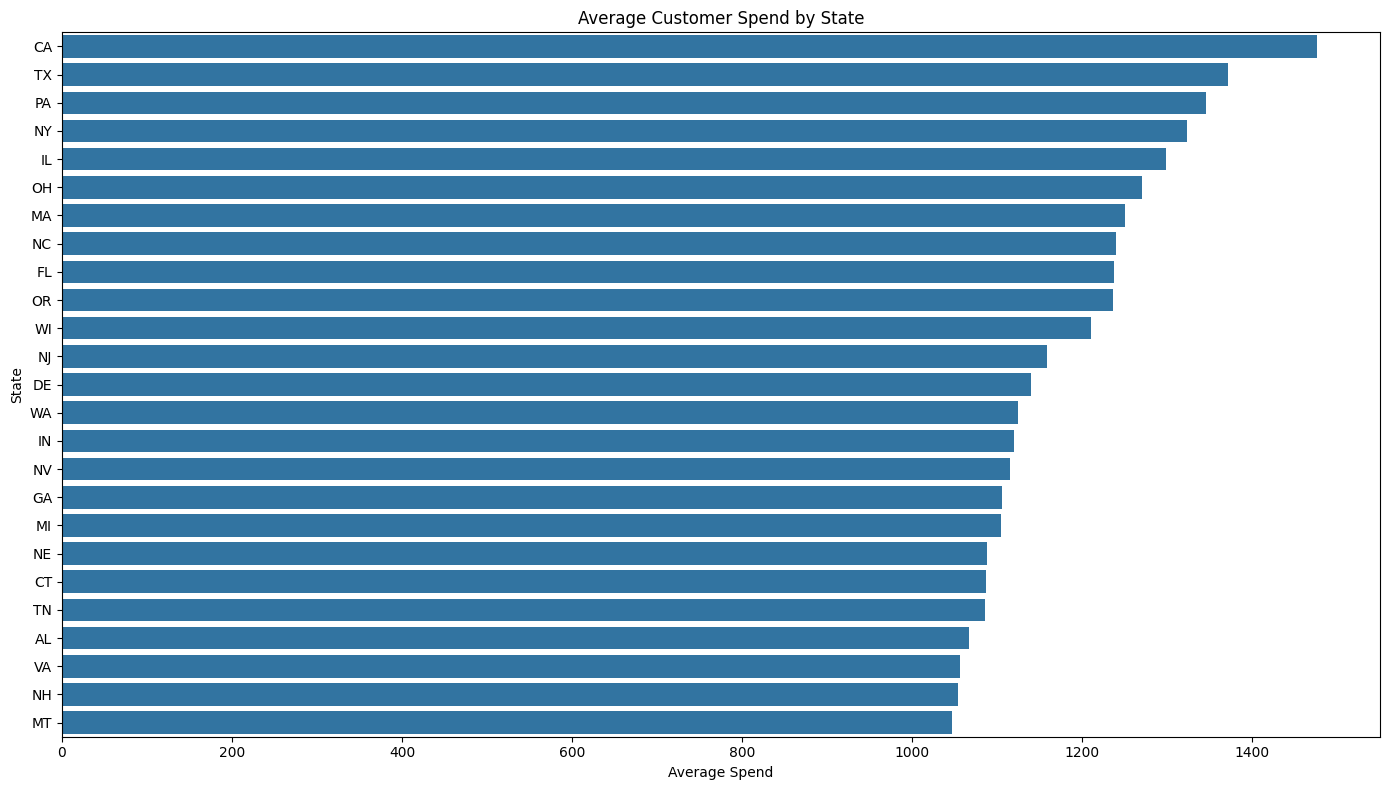

In [91]:
#Average spend per customer by state
state_customer_spend = (
    cleaned_data
    .groupBy(
        "Shipping Address State",
        "Survey ResponseID"
    )
    .agg(
        spark_sum("Revenue").alias("Customer_Spend")
    )
)
from pyspark.sql.functions import avg

avg_state_spend = (
    state_customer_spend
    .groupBy("Shipping Address State")
    .agg(
        avg("Customer_Spend").alias("Average_Spend")
    )
    .orderBy(
        col("Average_Spend").desc()
    )
    .limit(25)
)
avg_state_spend_pd = avg_state_spend.toPandas()
plt.figure(figsize=(14,8))

sns.barplot(
    data=avg_state_spend_pd,
    y="Shipping Address State",
    x="Average_Spend"
)

plt.title("Average Customer Spend by State")
plt.xlabel("Average Spend")
plt.ylabel("State")

plt.tight_layout()
plt.show()

#4. Customer Segmentation and Insights <font color = red>[45 marks]</font> <br>


## 4.1 Perform RFM Analysis <font color = red>[10 marks]</font> <br>

RFM Analysis is a powerful customer segmentation technique used to evaluate and quantify customer value based on three key dimensions:
- **Recency**,
- **Frequency**,
- **Monetary**.

This method is particularly effective in identifying high-value customers, optimizing marketing strategies, and improving customer retention in the e-commerce industry.


### 1. Recency (R)
Recency measures how recently a customer made a purchase Customers who have purchased more recently are more likely to respond to promotions and offers.
- **Application:** By ranking customers based on the number of days since their last transaction, you can prioritize those who are most engaged.

### 2. Frequency (F)
Frequency counts the number of purchases a customer has made over a given period.
Frequent purchasers tend to be more loyal and are often a source of recurring revenue.
- **Application:** Analyzing purchase frequency helps in identifying consistent buyers and understanding their buying patterns.

### 3. Monetary (M)
Monetary value represents the total amount of money a customer has spent.
Customers who spend more are often more profitable, making them ideal targets for retention and upsell strategies.
- **Application:** By assessing the monetary contribution, you can distinguish between high-value and low-value customers.


### Prepare data for RFM Analysis <font color = red>[2 marks]</font> <br>


In [93]:
from pyspark.sql.functions import datediff, max, count, sum, lit

# Get the latest order date in the dataset

from pyspark.sql.functions import max

latest_date = cleaned_data.select(
    max("Order Date")
).collect()[0][0]

print("Latest Order Date:", latest_date)

# Calculate RFM metrics
from pyspark.sql.functions import datediff, count, sum, lit

rfm = (
    cleaned_data
    .groupBy("Survey ResponseID")
    .agg(
        datediff(
            lit(latest_date),
            max("Order Date")
        ).alias("Recency"),

        count("Order Date").alias("Frequency"),

        sum("Revenue").alias("Monetary")
    )
)

# Filter out customers with no purchases
rfm = rfm.filter(
    rfm["Frequency"] > 0
)

# Show RFM data
rfm.show(10)

Latest Order Date: 2024-08-15
+-----------------+-------+---------+------------------+
|Survey ResponseID|Recency|Frequency|          Monetary|
+-----------------+-------+---------+------------------+
|R_1mxX9jjBSLwxiDU|    524|      248|           2765.26|
|R_1jO4s7oht3pyKEc|    518|      628|13287.830000000005|
|R_1eWdieBjoYJXAYv|    606|      965|27099.969999999976|
|R_1gG5xibh48txT6f|    523|      611|13311.660000000002|
|R_1esG9Jlh9NISLaO|    529|      368| 6881.200000000002|
|       B08F77YVYB|    848|        1|              8.99|
|R_10TV1zyi4yCEEkl|    525|     1124| 29788.35999999996|
|R_25yKg0PVMOCRZXm|    531|       65|1078.1499999999999|
|R_297dOANqCntVXou|    600|      588|11329.400000000005|
|R_1l6oxKA9uiM9GUo|    632|      174| 5240.860000000001|
+-----------------+-------+---------+------------------+
only showing top 10 rows



In [94]:
rfm.describe().show()

+-------+---------------------+------------------+------------------+------------------+
|summary|    Survey ResponseID|           Recency|         Frequency|          Monetary|
+-------+---------------------+------------------+------------------+------------------+
|  count|                15975|             15976|             15976|             15976|
|   mean| 3.5727278694726667E9|1003.2160115172759|115.11154231347021| 2745.783003254535|
| stddev| 4.1458677177149625E9|489.17599941792537|285.12752715892265| 6551.909504099286|
|    min| ""Read"" and ""Na...|                 0|                 1|              0.01|
|    max|（Banneton Brotfor...|              2418|              5258|112348.35999999971|
+-------+---------------------+------------------+------------------+------------------+



In [95]:
from pyspark.sql.functions import log1p

# Apply log transformation to skewed features
from pyspark.sql.functions import log1p

rfm = (
    rfm
    .withColumn(
        "Recency_log",
        log1p("Recency")
    )
    .withColumn(
        "Frequency_log",
        log1p("Frequency")
    )
    .withColumn(
        "Monetary_log",
        log1p("Monetary")
    )
)
# Convert to Pandas DataFrame (for scikit-learn compatibility)
rfm_pd = rfm.select(
    "Recency_log",
    "Frequency_log",
    "Monetary_log"
).toPandas()
# Scale features using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_pd)

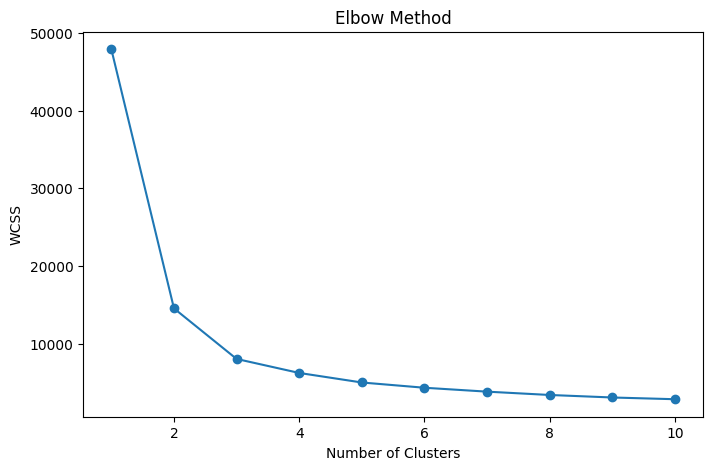

In [96]:
from sklearn.cluster import KMeans

# Calculate the Within-Cluster Sum of Squares (WCSS)
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)
# Plot the elbow curve with the number of clusters on the x-axis and WCSS on the y-axis
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [97]:
# Fit the K-Means model using the optimal number of clusters obtained after understanding the elblow plot
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    rfm_scaled
)
# Add the assigned cluster labels to the Pandas DataFrame and convert back to PySpark if needed
rfm_pd["Cluster"] = clusters

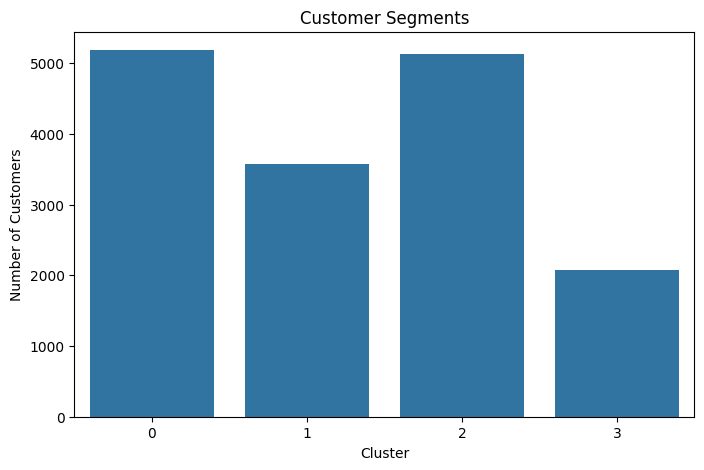

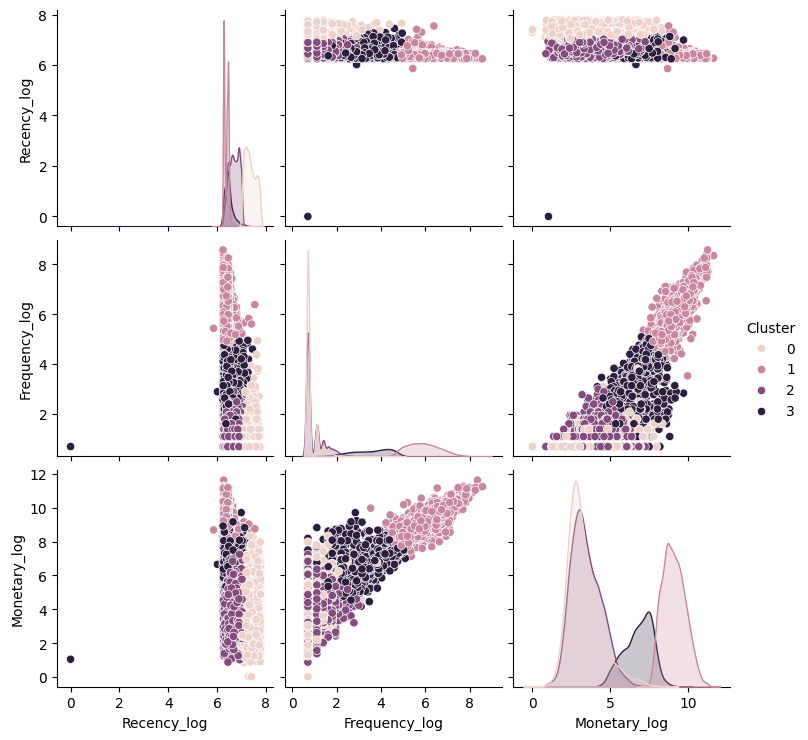

In [98]:
# Convert the full RFM dataset from PySpark DataFrame to Pandas DataFrame for visualisation
rfm_clustered = spark.createDataFrame(
    rfm_pd
)

plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm_pd,
    x="Cluster"
)

plt.title("Customer Segments")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()
# Generate a pairplot to visualise the relationships between the numeric RFM columns
import seaborn as sns

sns.pairplot(
    rfm_pd,
    vars=[
        "Recency_log",
        "Frequency_log",
        "Monetary_log"
    ],
    hue="Cluster",
    diag_kind="kde"
)

plt.show()

In [99]:
rfm_pd.groupby("Cluster").mean()

,Recency_log,Frequency_log,Monetary_log
Cluster,,,
0,7.362394,0.832575,3.288052
1,6.369870,5.899074,9.067006
2,6.685737,0.976165,3.442046
3,6.475407,3.513367,6.787013


### Behavioral Trends Analysis <font color = red>[8 marks]</font> <br>

Perform RFM analysis to study the behavior of customers to tailor marketing strategies

In [ ]:
# Import necessary PySpark functions for data processing

# Group the dataset by 'Survey ResponseID' to calculate RFM (Recency, Frequency, Monetary) metrics

# Compute 'Recency' as the difference between the latest date and the most recent order date
# Compute 'Frequency' as the count of distinct product purchases (ASIN/ISBN)
# Compute 'Monetary' as the total spending sum for each customer

# Rename columns if required and normlise the distributions

# Convert the processed RFM dataset back to Pandas for sklearn compatibility for clustering

In [101]:
# Apply K-Means clustering

# Fit the K-Means model and predict cluster labels for each customer

# Add the predicted cluster labels to the Pandas DataFrame

# Convert the Pandas DataFrame back to a PySpark DataFrame

rfm_pd["Cluster"] = clusters

rfm_pd["Survey ResponseID"] = (
    rfm.select("Survey ResponseID")
    .toPandas()["Survey ResponseID"]
)

rfm_spark = spark.createDataFrame(rfm_pd)

Analyse the Cluster Distribution by Income <font color = red>[2 marks]</font> <br>


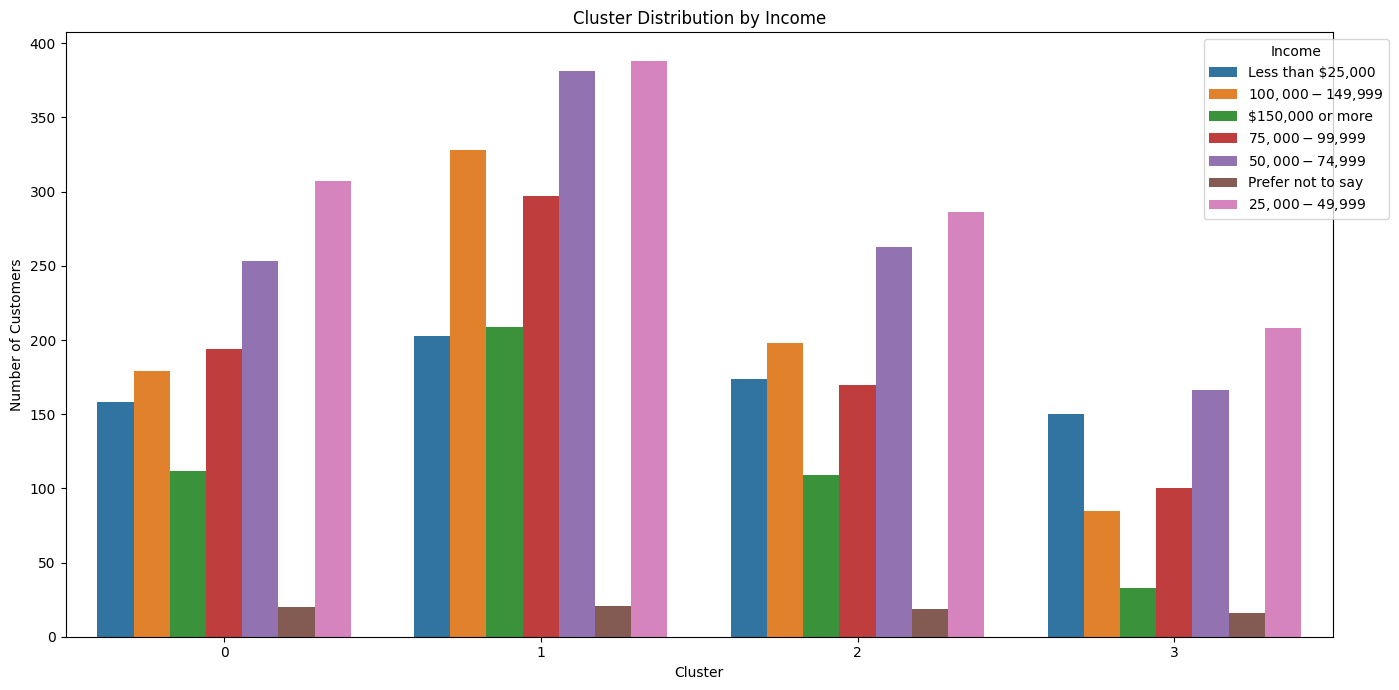

In [102]:
#Trend 1: Cluster Distribution by Income

cluster_income = (
    rfm_spark
    .join(
        survey.select(
            "Survey ResponseID",
            "Q-demos-income"
        ),
        on="Survey ResponseID",
        how="left"
    )
)

cluster_income_count = (
    cluster_income
    .groupBy(
        "Cluster",
        "Q-demos-income"
    )
    .count()
)

cluster_income_pd = (
    cluster_income_count
    .toPandas()
)

plt.figure(figsize=(14,7))

sns.barplot(
    data=cluster_income_pd,
    x="Cluster",
    y="count",
    hue="Q-demos-income"
)

plt.title("Cluster Distribution by Income")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.legend(
    title="Income",
    bbox_to_anchor=(1.05,1)
)

plt.tight_layout()
plt.show()
# Import the necessary function for counting records in PySpark

# Join the RFM dataset with the survey dataset using a common key

# Aggregate data to count the number of customers per Cluster-Income group

# Convert the aggregated data from PySpark DataFrame to Pandas DataFrame for visualisation

# Plot

Analyse the Average Spending by Cluster <font color = red>[2 marks]</font> <br>


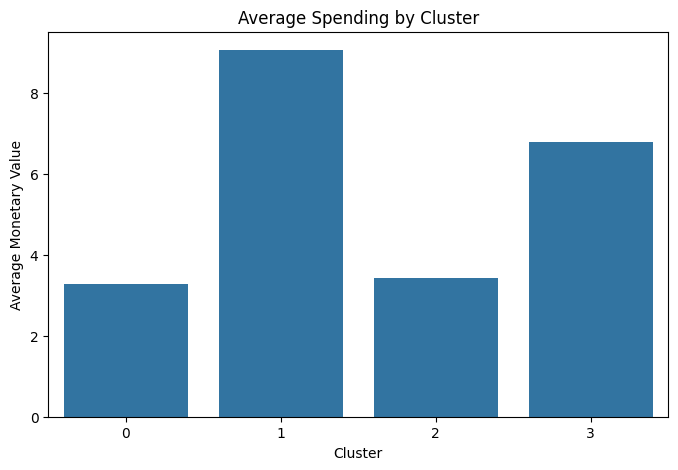

In [103]:
#Trend 2: Average Spending by Cluster

# Import the required function for calculating averages in PySpark

# Compute the average values of 'Recency_log', 'Frequency', and 'Monetary_log' for each customer cluster
from pyspark.sql.functions import avg

cluster_summary = (
    rfm_spark
    .groupBy("Cluster")
    .agg(
        avg("Recency_log").alias("Avg_Recency"),
        avg("Frequency_log").alias("Avg_Frequency"),
        avg("Monetary_log").alias("Avg_Monetary")
    )
)

# Convert the aggregated cluster summary from PySpark DataFrame to Pandas DataFrame for visualisation
cluster_summary_pd = (
    cluster_summary
    .toPandas()
)

# Generate a bar plot to visualise the average monetary spending per cluster
plt.figure(figsize=(8,5))

sns.barplot(
    data=cluster_summary_pd,
    x="Cluster",
    y="Avg_Monetary"
)

plt.title("Average Spending by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Monetary Value")

plt.show()

Analyse the Purchase Frequency vs. Recency <font color = red>[2 marks]</font> <br>


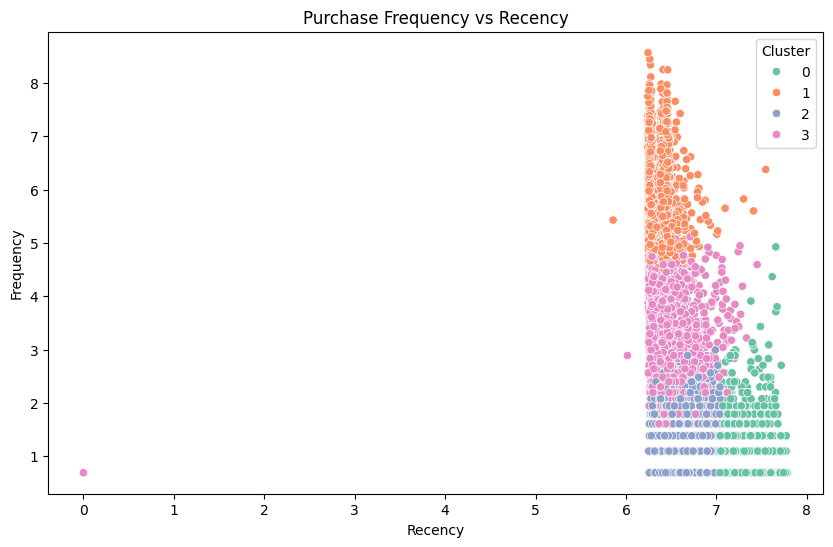

In [104]:
#Trend 3: Purchase Frequency vs. Recency

# Convert the RFM dataset from PySpark DataFrame to Pandas DataFrame for visualisation
rfm_plot = rfm_spark.toPandas()

# Generate a scatter plot to analyse the relationship between Purchase Frequency and Recency
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm_plot,
    x="Recency_log",
    y="Frequency_log",
    hue="Cluster",
    palette="Set2"
)

plt.title("Purchase Frequency vs Recency")
plt.xlabel("Recency")
plt.ylabel("Frequency")

plt.show()

Analyse the top categories by clusters <font color = red>[2 marks]</font> <br>


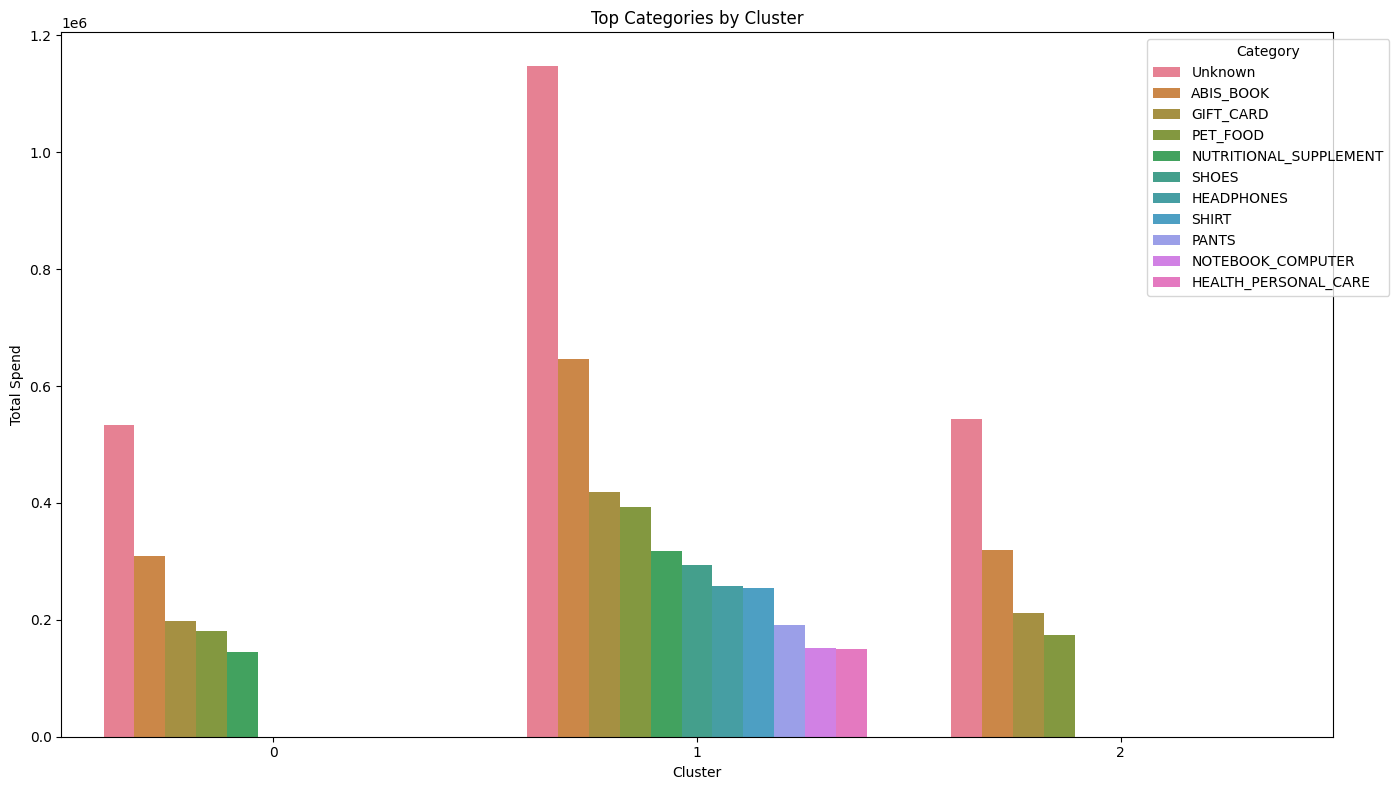

In [105]:
#Trend 4: Top Categories by Cluster

# Import the necessary function to calculate the sum in PySpark

# Join the merged dataset with the RFM dataset to associate each customer with their respective cluster
cluster_purchase = (
    cleaned_data
    .join(
        rfm_spark.select(
            "Survey ResponseID",
            "Cluster"
        ),
        on="Survey ResponseID",
        how="inner"
    )
)

# Group the filtered data by 'Category' and compute the total spending in each category
cluster_category = (
    cluster_purchase
    .groupBy(
        "Cluster",
        "Category"
    )
    .agg(
        sum("Revenue").alias("Total_Spend")
    )
)

# Order the categories by total spending in descending order and select the top 5 highest spending categories
top_categories = (
    cluster_category
    .orderBy(
        col("Total_Spend").desc()
    )
    .limit(20)
)

# Convert the top categories dataset from PySpark DataFrame to Pandas DataFrame for visualisation

top_categories_pd = (
    top_categories
    .toPandas()
)
# Plot the cluster
plt.figure(figsize=(14,8))

sns.barplot(
    data=top_categories_pd,
    x="Cluster",
    y="Total_Spend",
    hue="Category"
)

plt.title("Top Categories by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Total Spend")

plt.legend(
    bbox_to_anchor=(1.05,1),
    title="Category"
)

plt.tight_layout()
plt.show()

## 4.2 Insights <font color = red>[35 marks]</font> <br>


### 4.2.1 When to schedule effective promotions. <font color = red>[3 marks]</font> <br>

Compare sales across weekdays to schedule effective promotions

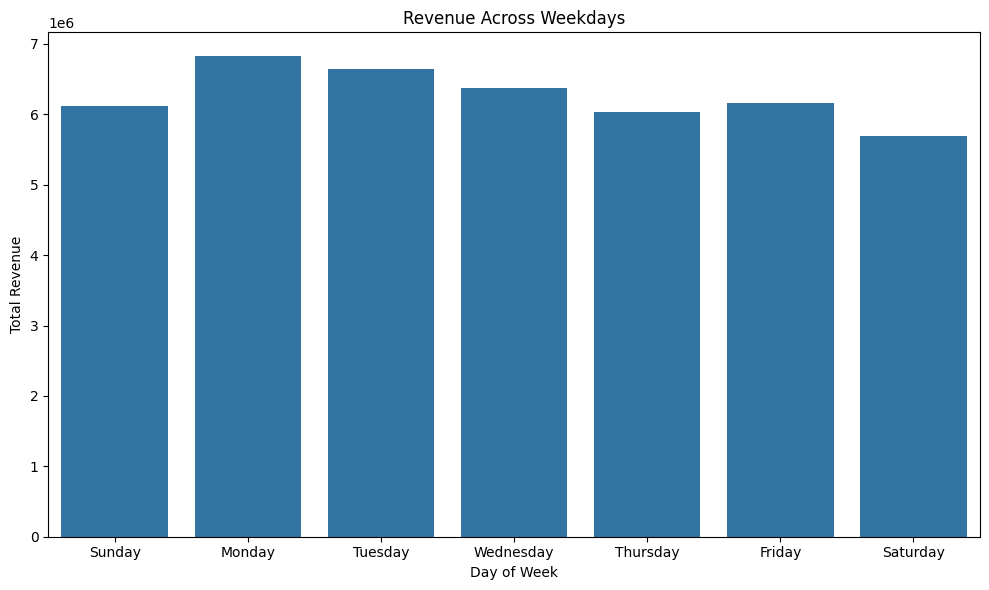

In [106]:
#Compare sales across weekdays to schedule effective promotions

from pyspark.sql.functions import dayofweek

# Extract day of the week (1 = Sunday, 7 = Saturday)
weekday_sales = cleaned_data.withColumn(
    "Day_Number",
    dayofweek("Order Date")
)
# Group by weekday and sum total sales
from pyspark.sql.functions import when

weekday_sales = (
    weekday_sales
    .withColumn(
        "Day_Name",
        when(weekday_sales.Day_Number == 1, "Sunday")
        .when(weekday_sales.Day_Number == 2, "Monday")
        .when(weekday_sales.Day_Number == 3, "Tuesday")
        .when(weekday_sales.Day_Number == 4, "Wednesday")
        .when(weekday_sales.Day_Number == 5, "Thursday")
        .when(weekday_sales.Day_Number == 6, "Friday")
        .otherwise("Saturday")
    )
)
from pyspark.sql.functions import sum as spark_sum

weekday_revenue = (
    weekday_sales
    .groupBy("Day_Number", "Day_Name")
    .agg(
        spark_sum("Revenue").alias("Total_Revenue")
    )
    .orderBy("Day_Number")
)
# Convert to Pandas for visualisation
weekday_revenue_pd = weekday_revenue.toPandas()
# Plot sales by weekday
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=weekday_revenue_pd,
    x="Day_Name",
    y="Total_Revenue"
)

plt.title("Revenue Across Weekdays")
plt.xlabel("Day of Week")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

### 4.2.2 Top-selling Products <font color = red>[2 marks]</font> <br>

Identify top-selling products by considering revenue and engagement metrics

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+----------+
|Title                                                                                                                                                                  |Total_Revenue     |Engagement|
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+----------+
|Unknown                                                                                                                                                                |2317770.5399998887|89481     |
|Amazon.com Gift Card Balance Reload                                                                                                                                    |226175.22000000006|8282      |


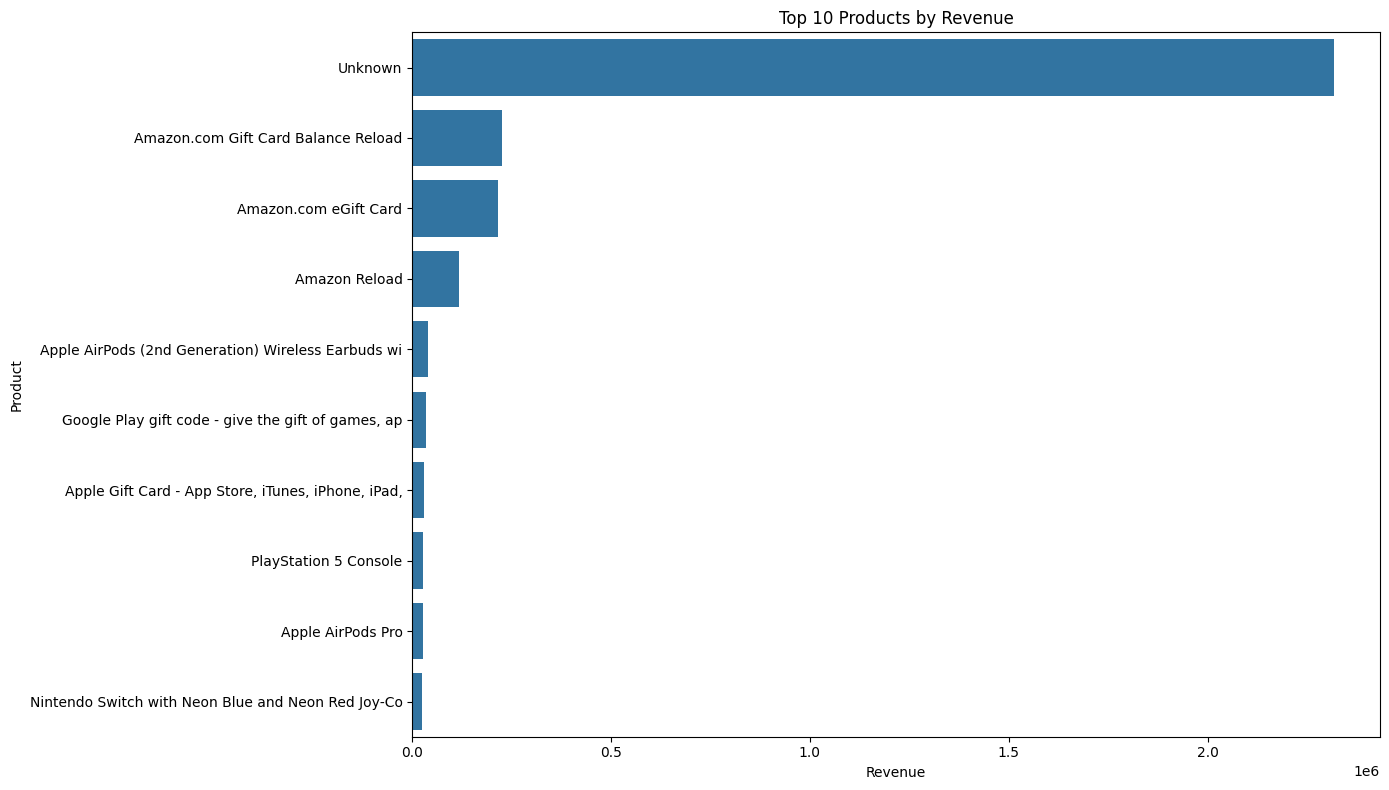

In [107]:
#Identify top-selling products using revenue and engagement metrics

# Group by product and sum revenue
from pyspark.sql.functions import sum as spark_sum, count, col

product_performance = (
    cleaned_data
    .groupBy("Title")
    .agg(
        spark_sum("Revenue").alias("Total_Revenue"),
        count("*").alias("Engagement")
    )
)
# Get top 10 products by revenue
top_products_revenue = (
    product_performance
    .orderBy(
        col("Total_Revenue").desc()
    )
    .limit(10)
)

top_products_revenue.show(truncate=False)
# Convert to Pandas for visualisation
top_products_revenue_pd = (
    top_products_revenue
    .toPandas()
)

top_products_revenue_pd["Short_Title"] = (
    top_products_revenue_pd["Title"]
    .str.slice(0, 50)
)
# Plot top products by revenue
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,8))

sns.barplot(
    data=top_products_revenue_pd,
    y="Short_Title",
    x="Total_Revenue"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

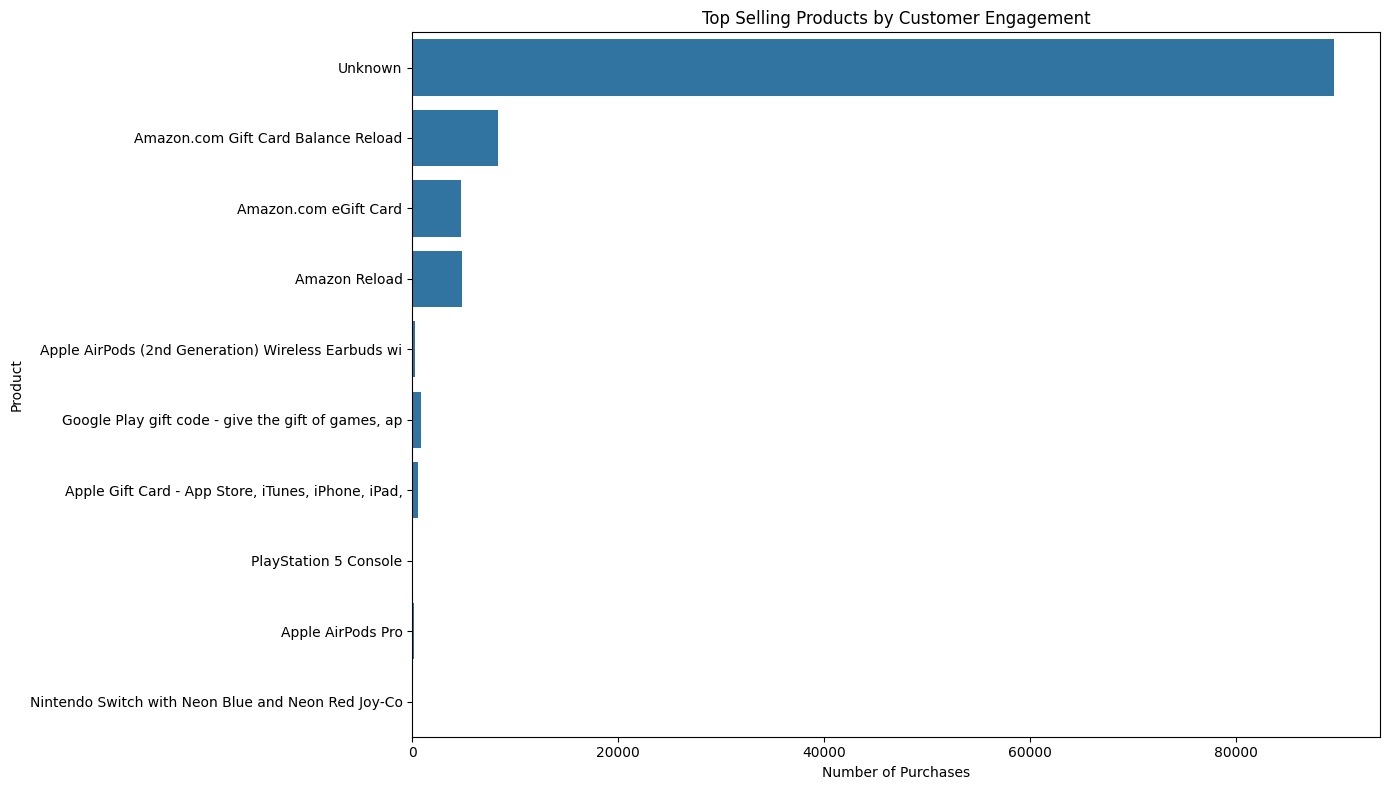

In [108]:
# engagement metrics
plt.figure(figsize=(14,8))

sns.barplot(
    data=top_products_revenue_pd,
    y="Short_Title",
    x="Engagement"
)

plt.title("Top Selling Products by Customer Engagement")
plt.xlabel("Number of Purchases")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [109]:
top_products_revenue_pd[
    [
        "Short_Title",
        "Total_Revenue",
        "Engagement"
    ]
]

,Short_Title,Total_Revenue,Engagement
0,Unknown,2317770.54,89481
1,Amazon.com Gift Card Balance Reload,226175.22,8282
2,Amazon.com eGift Card,215947.95,4682
3,Amazon Reload,117078.49,4876
4,Apple AirPods (2nd Generation) Wireless Earbud...,39276.84,289
5,Google Play gift code - give the gift of games...,35219.92,833
6,"Apple Gift Card - App Store, iTunes, iPhone, i...",28382.79,542
7,PlayStation 5 Console,26913.35,53
8,Apple AirPods Pro,25942.00,123
9,Nintendo Switch with Neon Blue and Neon Red Jo...,24276.47,80


### 4.2.3 State-wise revenue Distribution <font color = red>[5 marks]</font> <br>

Assess state-wise revenue to focus on high-growth areas

+----------------------+------------------+
|Shipping Address State|     Total_Revenue|
+----------------------+------------------+
|                    CA| 4320755.399999528|
|                    TX| 3247992.539999746|
|                    FL| 2671910.959999862|
|                    NY|   2358050.4299999|
|               Unknown|2258914.5799999554|
|                    PA|  2194848.50999993|
|                    OH|1956486.2299999539|
|                    IL|1734260.9699999772|
|                    NC|1686451.0699999824|
|                    MI|1404837.1300000143|
+----------------------+------------------+
only showing top 10 rows



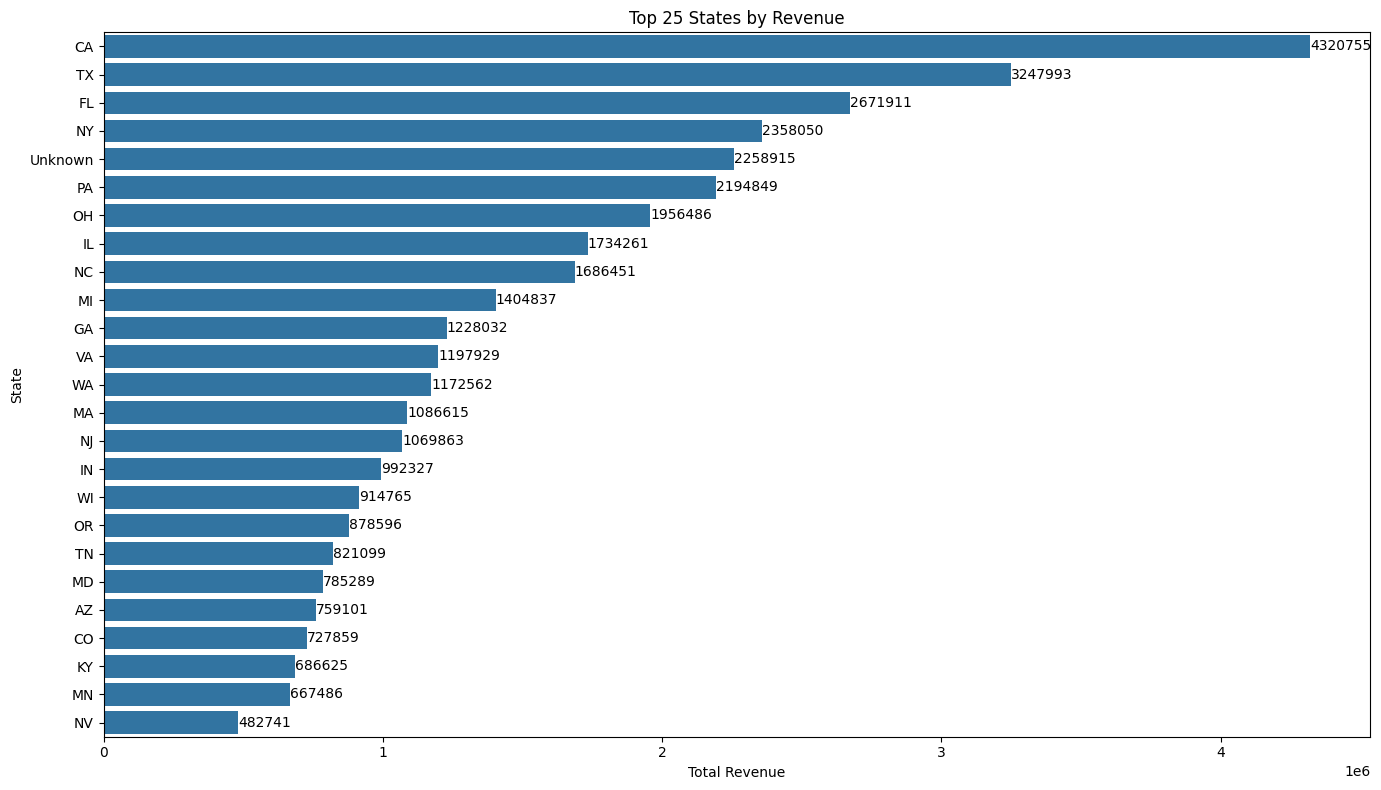

In [110]:
#Assess state-wise revenue to focus on high-growth areas

# Group by state and sum revenue
from pyspark.sql.functions import sum as spark_sum, col

state_revenue = (
    cleaned_data
    .groupBy("Shipping Address State")
    .agg(
        spark_sum("Revenue").alias("Total_Revenue")
    )
    .orderBy(
        col("Total_Revenue").desc()
    )
)

state_revenue.show(10)

# Convert to Pandas for visualisation
state_revenue_pd = (
    state_revenue
    .limit(25)
    .toPandas()
)
# Plot revenue by state
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,8))

ax = sns.barplot(
    data=state_revenue_pd,
    y="Shipping Address State",
    x="Total_Revenue"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f'
    )

plt.title("Top 25 States by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### 4.2.4 Repeat Purchase Behavior <font color = red>[5 marks]</font> <br>

Examine repeat purchase behavior to enhance retention initiatives.

In [111]:
#Examine repeat purchase behavior to enhance retention initiatives

from pyspark.sql.functions import count, col

# Count total purchases per customer

customer_purchases = (
    cleaned_data
    .groupBy("Survey ResponseID")
    .agg(
        count("*").alias("Total_Purchases")
    )
)
# Filter for repeat customers (those with more than one purchase)
repeat_customers = (
    customer_purchases
    .filter(
        col("Total_Purchases") > 1
    )
)
# Show sample data
repeat_customers.show(10)

+-----------------+---------------+
|Survey ResponseID|Total_Purchases|
+-----------------+---------------+
|R_1mxX9jjBSLwxiDU|            248|
|R_1jO4s7oht3pyKEc|            628|
|R_1eWdieBjoYJXAYv|            965|
|R_1gG5xibh48txT6f|            611|
|R_1esG9Jlh9NISLaO|            368|
|R_10TV1zyi4yCEEkl|           1124|
|R_25yKg0PVMOCRZXm|             65|
|R_297dOANqCntVXou|            588|
|R_1l6oxKA9uiM9GUo|            174|
|R_1li5HiNnFHiD7yw|            158|
+-----------------+---------------+
only showing top 10 rows



In [112]:
print(
    "Number of Repeat Customers:",
    repeat_customers.count()
)

Number of Repeat Customers: 8696


Repeat Customer Percentage: 54.43%


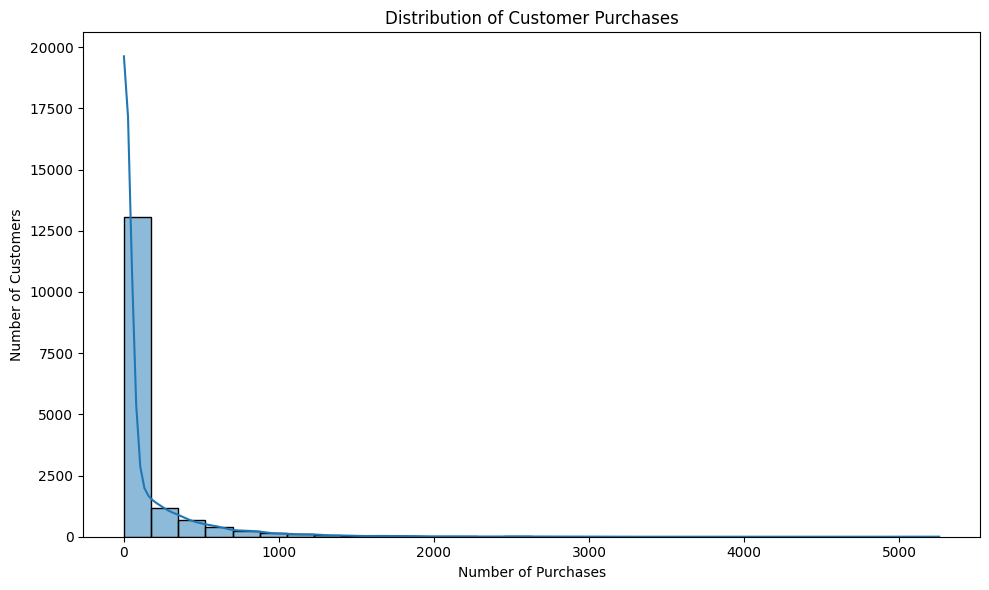

In [113]:
total_customers = customer_purchases.count()

repeat_count = repeat_customers.count()

repeat_percentage = (
    repeat_count / total_customers
) * 100

print(
    f"Repeat Customer Percentage: {repeat_percentage:.2f}%"
)

repeat_pd = (
    customer_purchases
    .toPandas()
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    repeat_pd["Total_Purchases"],
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Purchases")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


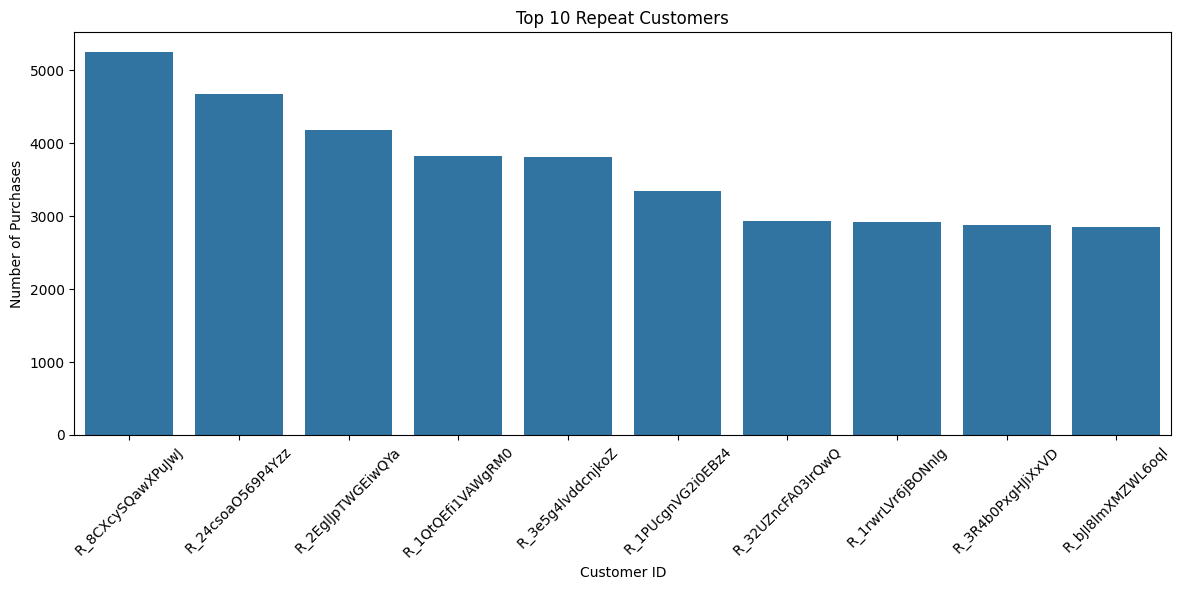

In [114]:
#top 10 most loyal customers

top_repeat = (
    customer_purchases
    .orderBy(
        col("Total_Purchases").desc()
    )
    .limit(10)
)

top_repeat_pd = top_repeat.toPandas()

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_repeat_pd,
    x="Survey ResponseID",
    y="Total_Purchases"
)

plt.title("Top 10 Repeat Customers")
plt.xlabel("Customer ID")
plt.ylabel("Number of Purchases")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.2.5 Flagging Potential Fraud <font color = red>[5 marks]</font> <br>

Identify irregular transaction patterns to flag potential fraud.

Mean Spending: 2745.78
Standard Deviation: 6551.91
Fraud Threshold: 22401.51
+-----------------+------------------+
|Survey ResponseID|Total_Spent       |
+-----------------+------------------+
|R_2EglJpTWGEiwQYa|112348.35999999971|
|R_4PhRzF4UI9ooLh7|78446.33999999985 |
|R_8CXcySQawXPuJwJ|76590.77999999955 |
|R_24csoaO569P4Yzz|74143.62999999966 |
|R_2YR2Yn7wGzAeAj0|73646.60999999984 |
|R_1QtQEfi1VAWgRM0|73087.9899999997  |
|R_AKBlDprDMrv4M7v|72549.87999999983 |
|R_cucdDIXhmDRBfZT|72219.76999999987 |
|R_3R4b0PxgHJiXxVD|71988.0499999998  |
|R_40engukXSxhrtF7|70123.77999999997 |
|R_1C4nKyrv0w2thJn|67709.60999999975 |
|R_2z7rLZb69WuqDdf|66954.89999999982 |
|R_32UZncFA03IrQwQ|66635.33999999976 |
|R_1NDq0rxoUSu6oyz|64725.35999999978 |
|R_32Mm71oAJq2K9XK|64354.74999999976 |
|R_1rwrLVr6jBONnIg|63398.499999999796|
|R_3e5g4lvddcnjkoZ|61932.97999999974 |
|R_1Q9JeeKncbbLcz0|59508.40999999982 |
|R_3qTFp0FJqUeMhVZ|59369.41999999984 |
|R_24nLvo5DCDemQ4Q|58029.96999999981 |
+-----------------+-------

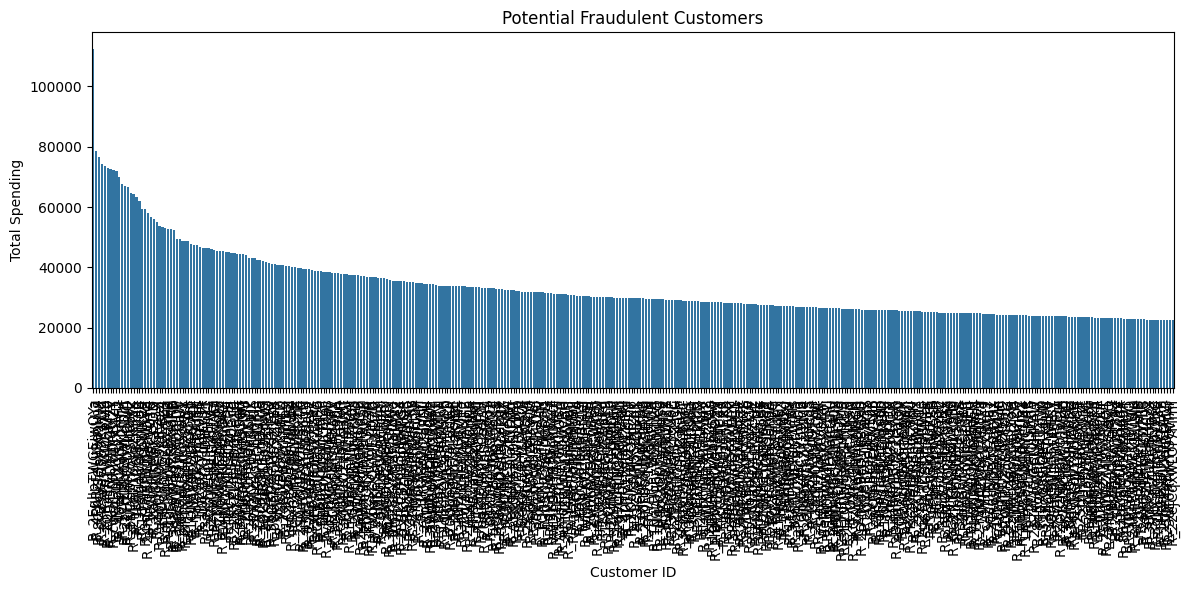

In [115]:
#Identify irregular transaction patterns to flag potential fraud

from pyspark.sql.functions import col, avg, stddev

# Calculate the threshold for unusually high spending
from pyspark.sql.functions import sum as spark_sum

customer_spending = (
    cleaned_data
    .groupBy("Survey ResponseID")
    .agg(
        spark_sum("Revenue").alias("Total_Spent")
    )
)
# Consider spending to be unusually high if the total spent is greater than the mean + 3 * std dev
from pyspark.sql.functions import avg, stddev

stats = customer_spending.agg(
    avg("Total_Spent").alias("Mean_Spend"),
    stddev("Total_Spent").alias("Std_Spend")
).collect()[0]

mean_spend = stats["Mean_Spend"]
std_spend = stats["Std_Spend"]

threshold = mean_spend + (3 * std_spend)

print("Mean Spending:", round(mean_spend, 2))
print("Standard Deviation:", round(std_spend, 2))
print("Fraud Threshold:", round(threshold, 2))

# Filter transactions that exceed the threshold
suspicious_transactions = (
    customer_spending
    .filter(
        col("Total_Spent") > threshold
    )
    .orderBy(
        col("Total_Spent").desc()
    )
)

# Show suspicious transactions
suspicious_transactions.show(20, truncate=False)

print(
    "Number of Suspicious Customers:",
    suspicious_transactions.count()
)


suspicious_pd = suspicious_transactions.toPandas()


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=suspicious_pd,
    x="Survey ResponseID",
    y="Total_Spent"
)

plt.title("Potential Fraudulent Customers")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 4.2.6 Demand Variations across product categories <font color = red>[5 marks]</font> <br>

Perform inventory management by monitoring demand variations across product categories.

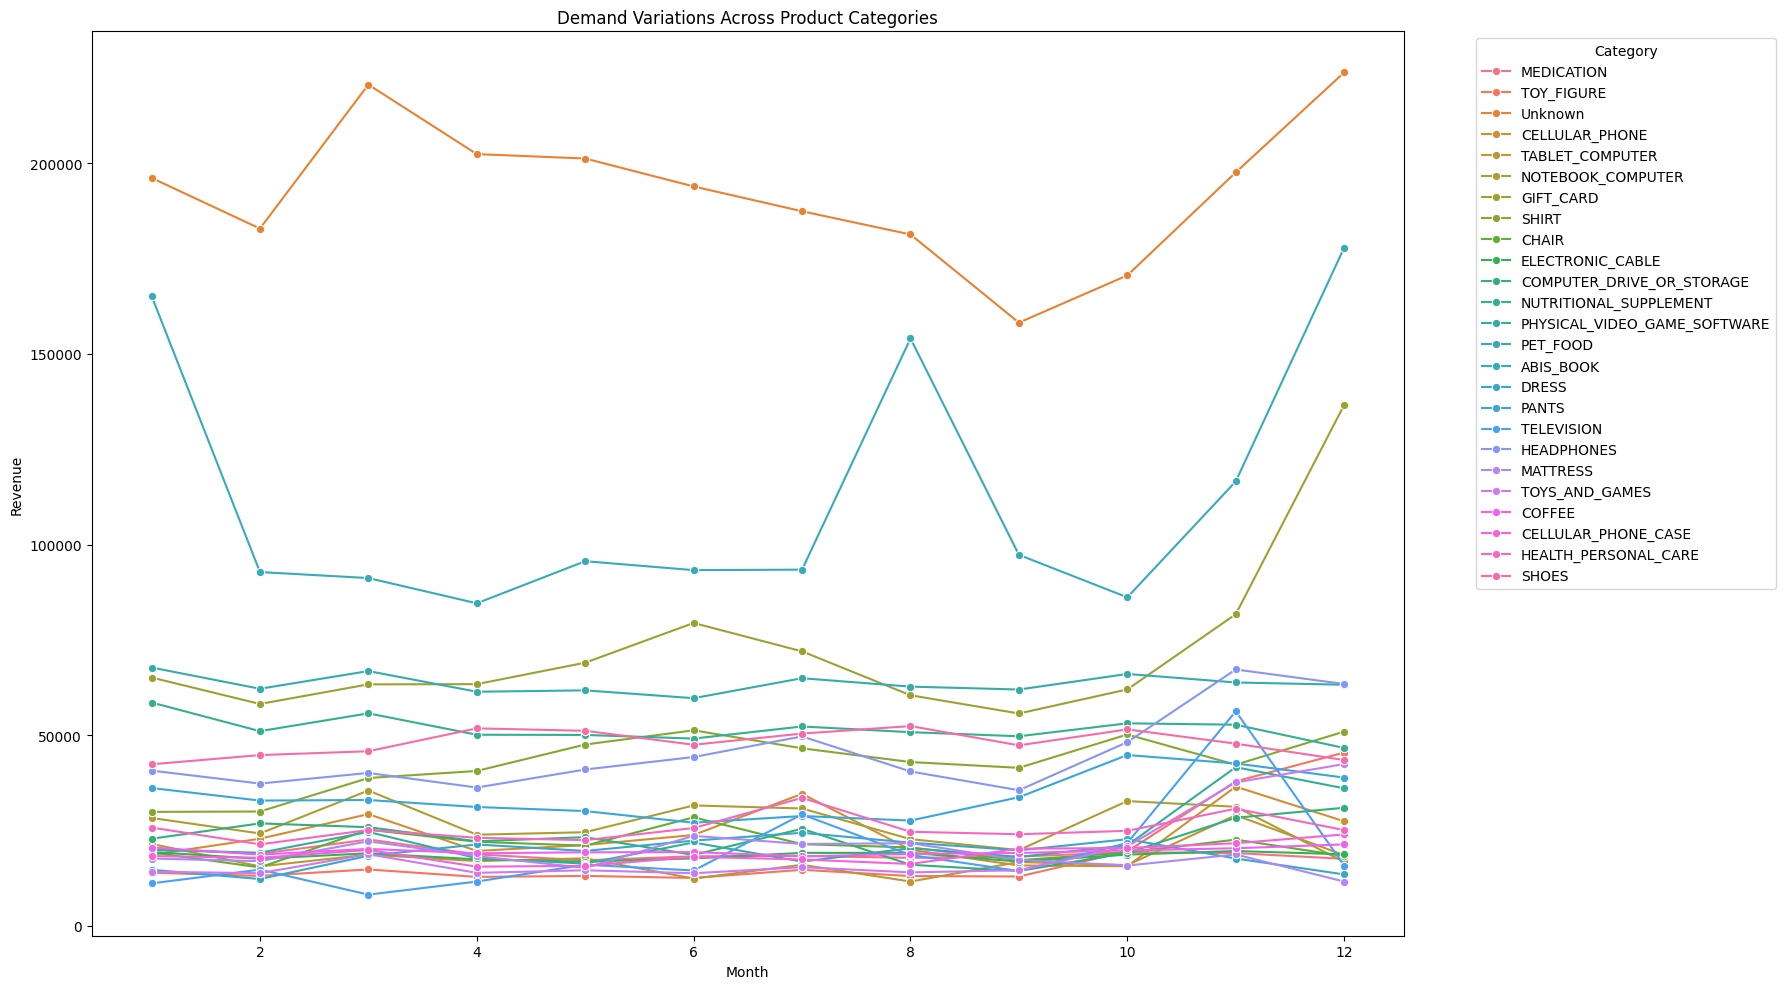

In [116]:
#Monitor demand variations across product categories (Top 25) for inventory management

from pyspark.sql.functions import col, sum
import matplotlib.pyplot as plt
import seaborn as sns

# Group by category and month, summing total revenue
from pyspark.sql.functions import month

cleaned_data = cleaned_data.withColumn(
    "Order_Month",
    month("Order Date")
)
#Monitor demand variations across product categories (Top 25) for inventory management
from pyspark.sql.functions import sum, col

category_trends = (
    cleaned_data
    .groupBy(
        "Category",
        "Order_Month"
    )
    .agg(
        sum("Revenue").alias("Total_Revenue")
    )
)

# Group by category and month, summing total revenue

# Compute total revenue per category
category_revenue = (
    cleaned_data
    .groupBy("Category")
    .agg(
        sum("Revenue").alias("Category_Revenue")
    )
)
# Get the top 25 categories by total revenue
top_categories = (
    category_revenue
    .orderBy(
        col("Category_Revenue").desc()
    )
    .limit(25)
)
# Filter category_trends to include only top 25 categories
top_category_list = [
    row["Category"]
    for row in top_categories.collect()
]

filtered_category_trends = (
    category_trends
    .filter(
        col("Category").isin(top_category_list)
    )
)
# Convert to Pandas for visualisation
category_trends_pd = (
    filtered_category_trends
    .toPandas()
)
# Plot revenue trends for top 25 categories
category_trends_pd = (
    filtered_category_trends
    .toPandas()
)

# Plot revenue trends for top 25 categories
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,10))

sns.lineplot(
    data=category_trends_pd,
    x="Order_Month",
    y="Total_Revenue",
    hue="Category",
    marker="o"
)

plt.title(
    "Demand Variations Across Product Categories"
)
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.legend(
    bbox_to_anchor=(1.05,1),
    title="Category"
)

plt.tight_layout()
plt.show()

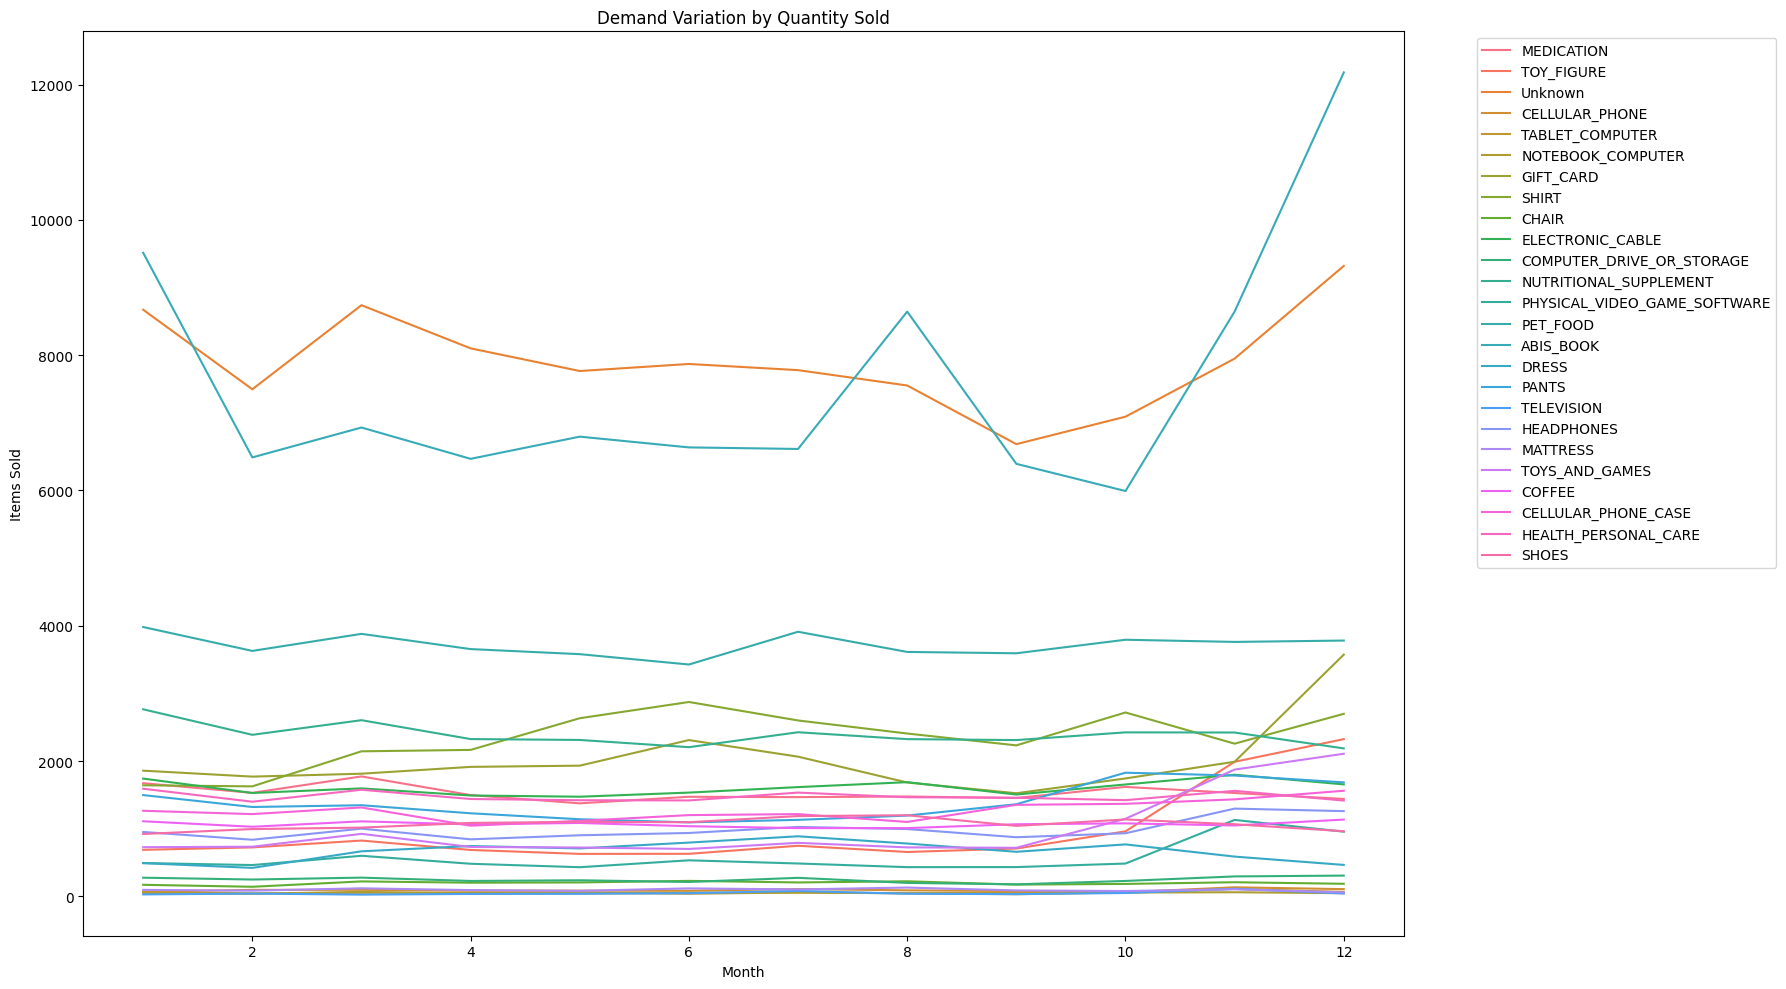

In [117]:
#Demand variation by quantity sold
category_quantity = (
    cleaned_data
    .groupBy(
        "Category",
        "Order_Month"
    )
    .agg(
        sum("Quantity").alias("Items_Sold")
    )
)

category_quantity_pd = (
    category_quantity
    .filter(
        col("Category").isin(top_category_list)
    )
    .toPandas()
)

plt.figure(figsize=(18,10))

sns.lineplot(
    data=category_quantity_pd,
    x="Order_Month",
    y="Items_Sold",
    hue="Category"
)

plt.title(
    "Demand Variation by Quantity Sold"
)

plt.xlabel("Month")
plt.ylabel("Items Sold")

plt.legend(
    bbox_to_anchor=(1.05,1)
)

plt.tight_layout()
plt.show()

### 4.2.7 Assess how bulk purchases affect revenue and supply chain operations <font color = red>[5 marks]</font> <br>

Analyse the impact of how bulk purchasing behavior affects revenue and the overall supply chain operations.

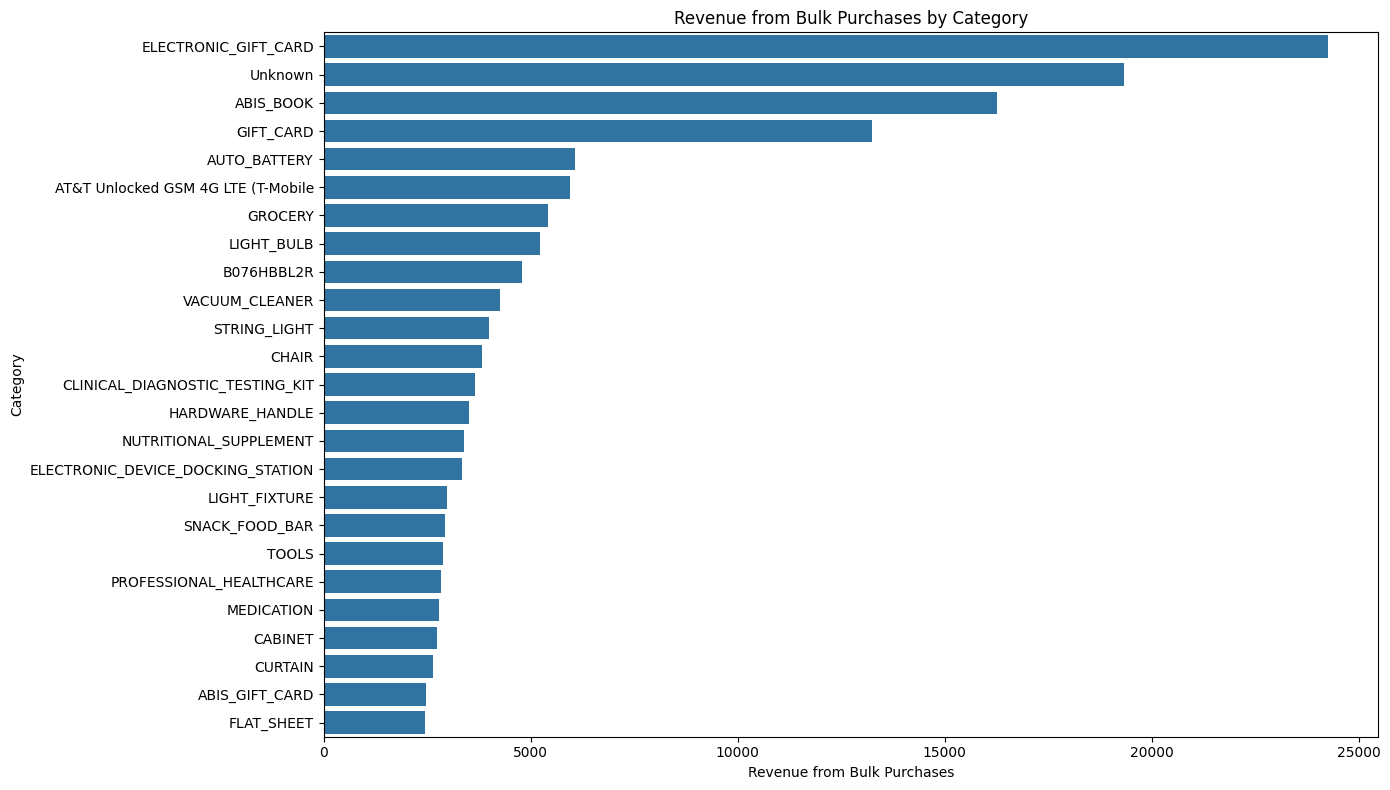

In [118]:
#Assess how bulk purchases affect revenue and supply chain operations

# Filter bulk purchases (Quantity > 5) and compute total revenue per category
from pyspark.sql.functions import col, sum
import matplotlib.pyplot as plt
import seaborn as sns

bulk_purchases = cleaned_data.filter(
    col("Quantity") > 5
)

bulk_category_revenue = (
    bulk_purchases
    .groupBy("Category")
    .agg(
        sum("Revenue").alias("Bulk_Revenue")
    )
)
# Select the top 25 categories by total revenue
top_bulk_categories = (
    bulk_category_revenue
    .orderBy(
        col("Bulk_Revenue").desc()
    )
    .limit(25)
)
# Convert to Pandas for visualisation
top_bulk_categories_pd = top_bulk_categories.toPandas()

# Plot revenue from bulk purchases (Top 25 categories)
plt.figure(figsize=(14,8))

sns.barplot(
    data=top_bulk_categories_pd,
    y="Category",
    x="Bulk_Revenue"
)

plt.title("Revenue from Bulk Purchases by Category")
plt.xlabel("Revenue from Bulk Purchases")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

Bulk purchases contribute 0.71% of total revenue.


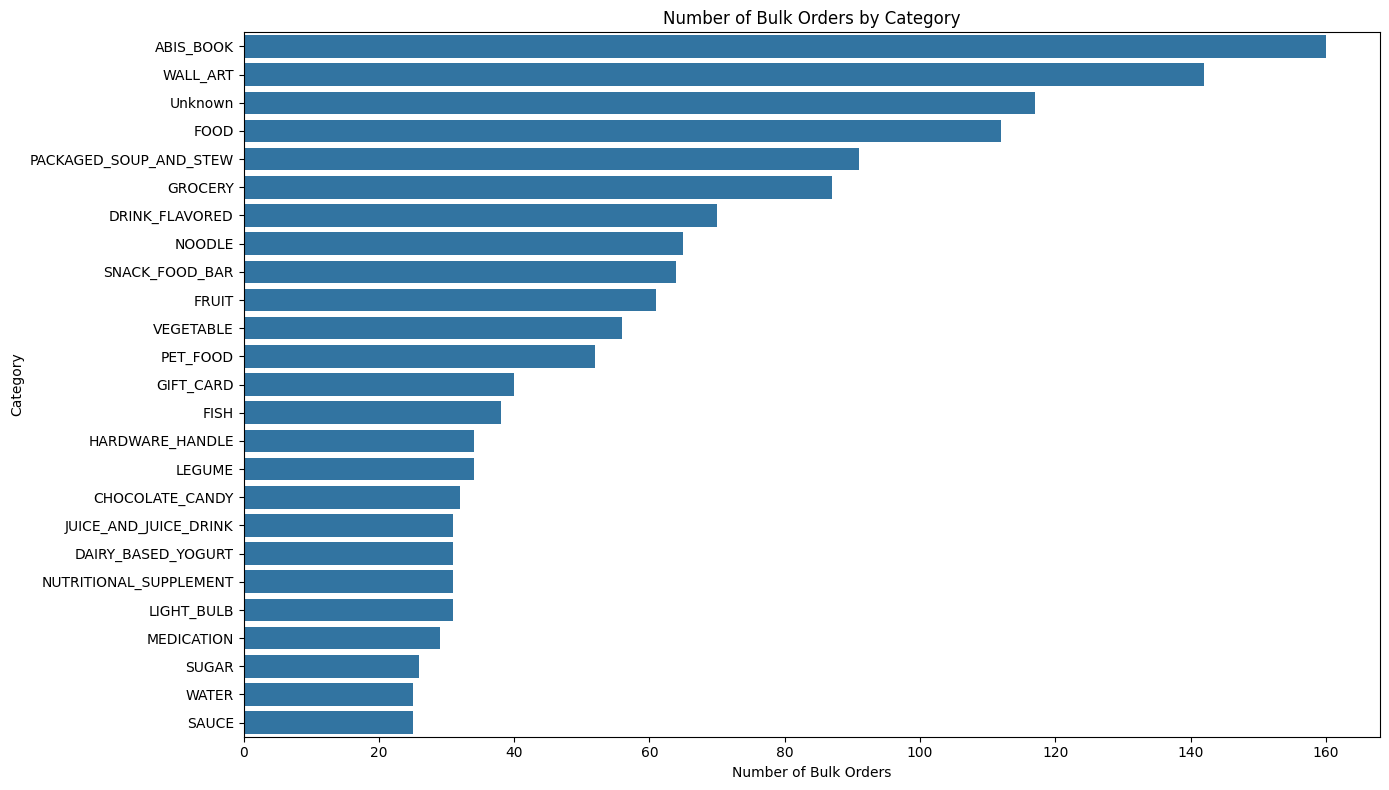

In [119]:
#Percentage of revenue coming from bulk purchases
total_revenue = (
    cleaned_data
    .agg(
        sum("Revenue").alias("Total_Revenue")
    )
    .collect()[0]["Total_Revenue"]
)

bulk_revenue = (
    bulk_purchases
    .agg(
        sum("Revenue").alias("Bulk_Revenue")
    )
    .collect()[0]["Bulk_Revenue"]
)

bulk_percentage = (
    bulk_revenue / total_revenue
) * 100

print(
    f"Bulk purchases contribute {bulk_percentage:.2f}% of total revenue."
)

bulk_orders = (
    bulk_purchases
    .groupBy("Category")
    .count()
    .orderBy(
        col("count").desc()
    )
    .limit(25)
)

bulk_orders_pd = bulk_orders.toPandas()

plt.figure(figsize=(14,8))

sns.barplot(
    data=bulk_orders_pd,
    y="Category",
    x="count"
)

plt.title("Number of Bulk Orders by Category")
plt.xlabel("Number of Bulk Orders")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

### 4.2.8 Compare lifecycle strategies <font color = red>[5 marks]</font> <br>

Compare new and established products to inform and compare lifecycle strategies to make informed decisions.

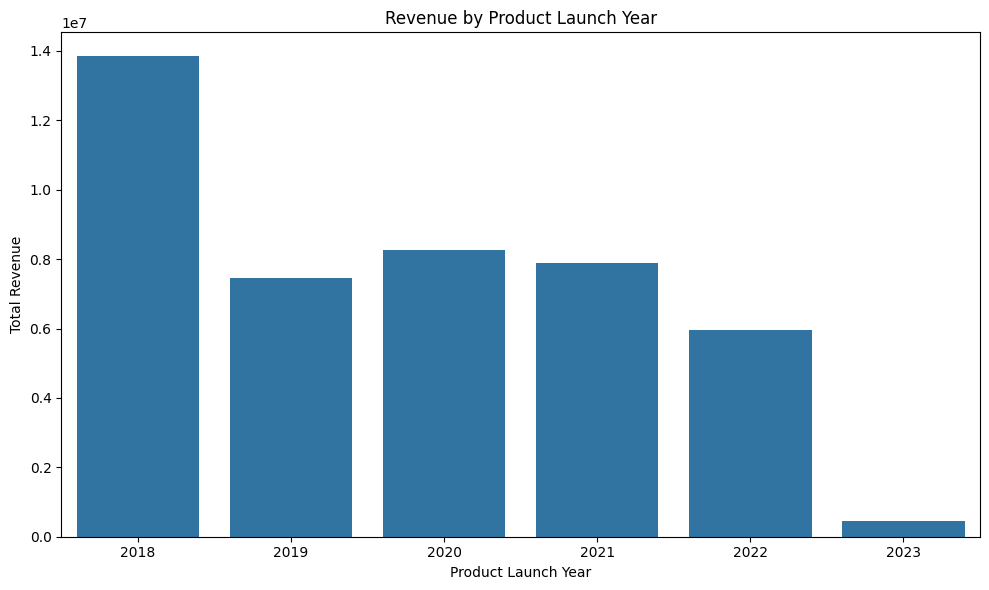

In [120]:
#Compare new and established products to inform lifecycle strategies

from pyspark.sql.functions import min, sum

# Compute "Launch Year" as the first recorded sale year for each product
from pyspark.sql.functions import min, year

product_launch = (
    cleaned_data
    .withColumn(
        "Sale_Year",
        year("Order Date")
    )
    .groupBy("Title")
    .agg(
        min("Sale_Year").alias("Launch_Year")
    )
)
# Join this back to the main dataset
product_lifecycle = (
    cleaned_data
    .join(
        product_launch,
        on="Title",
        how="left"
    )
)
# Now, we can compute revenue by launch year
from pyspark.sql.functions import sum

launch_year_revenue = (
    product_lifecycle
    .groupBy("Launch_Year")
    .agg(
        sum("Revenue").alias("Total_Revenue")
    )
    .orderBy("Launch_Year")
)
# Convert to Pandas
launch_year_pd = (
    launch_year_revenue
    .toPandas()
)
# Plot revenue vs. launch year
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=launch_year_pd,
    x="Launch_Year",
    y="Total_Revenue"
)

plt.title("Revenue by Product Launch Year")
plt.xlabel("Product Launch Year")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

#5 Conclusion <font color = red>[10 marks]</font> <br>

Write your conclusion.

Through data preparation, cleansing, exploratory data analysis, and customer segmentation approaches, this research examined consumer purchasing behavior utilizing Amazon purchase and survey datasets.

Significant trends in consumer purchase behavior across various time periods, product categories, customer demographics, and geographic regions were found by the investigation. Better inventory planning and promotional techniques were made possible by the identification of high-performing markets and times of increasing demand through seasonal trends and state-by-state revenue research.

Customers were successfully divided into various groups according to recency, frequency, and monetary value using RFM analysis and K-Means clustering. These client groups offer useful information for creating focused advertising campaigns, boosting individualized recommendations, and increasing customer retention.

While fraud detection systems assisted in identifying anomalous spending patterns that would need additional examination, the analysis of recurrent purchase behavior emphasized the significance of loyal customers in generating income. Supply chain optimization and product management techniques were also revealed through an examination of bulk buying patterns and product lifecycle trends.

All things considered, this study shows how e-commerce companies may make data-driven decisions, enhance consumer interaction, streamline operations, and boost profitability through focused business strategies by utilizing big data analytics and customer segmentation methodologies.